#Renewble Energy Project

# import liabrary / Font

In [145]:
import os
import math
import warnings
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm
from matplotlib.cm import ScalarMappable
import seaborn as sns

from IPython.display import HTML, display
from PIL import Image

import flagpy as fp
from plottable import ColumnDefinition, Table
from plottable.plots import image

warnings.filterwarnings('ignore')

In [146]:
FONT_PATH = os.path.join('fonts', 'Garuda.otf')

thai_font_name = None
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    thai_font_name = fm.FontProperties(fname=FONT_PATH).get_name()
else:
    # Fallback: a Thai-capable font already installed on this machine
    candidates = ['Garuda', 'Noto Sans Thai', 'Leelawadee UI', 'Leelawadee', 'Tahoma', 'Cordia New', 'Loma']
    installed = {f.name for f in fm.fontManager.ttflist}
    thai_font_name = next((c for c in candidates if c in installed), None)

if thai_font_name:
    plt.rcParams['font.family'] = thai_font_name
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.unicode_minus'] = False
    print(f'Thai font ready: "{thai_font_name}"')
else:
    print("No Thai font found. Make sure the 'fonts' folder (with Garuda.otf) "
          "sits next to this notebook.")

Thai font ready: "Garuda"


In [147]:
# Locate the bundled fonts from the notebook or workspace directory.
font_dirs = [Path('fonts'), Path('dads 5001') / 'fonts']
font_dir = next((p for p in font_dirs if (p / 'Garuda.otf').is_file()), None)
if font_dir is not None:
    for filename in ['Garuda.otf', 'Garuda-Bold.otf']:
        font_path = font_dir / filename
        if font_path.is_file():
            fm.fontManager.addfont(str(font_path))
    GARUDA = fm.FontProperties(fname=str(font_dir / 'Garuda.otf')).get_name()
else:
    GARUDA = globals().get('thai_font_name') or 'Tahoma'
DEJAVU = 'DejaVu Sans'
plt.rcParams['font.family'] = GARUDA
plt.rcParams['axes.unicode_minus'] = False


# Import file

In [148]:
url = 'https://raw.githubusercontent.com/Manasafang/Transition-or-Addition/main/renewable_energy_countries_selected_v7.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"Countries: {df['country'].nunique()}")
print(f"Years: {df['year'].min()} – {df['year'].max()}")
df.head()

Shape: (5381, 23)
Countries: 213
Years: 2000 – 2025


,country,continent,year,iso_code,gdp,electricity_generation,renewables_share_elec,fossil_share_elec,low_carbon_share_elec,solar_electricity,...,coal_electricity,gas_electricity,oil_electricity,other_renewable_electricity,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec
0,Afghanistan,Asia,2000,AFG,1.128379e+10,0.48,64.583,35.417,64.583,0.0,...,0.00,0.0,0.17,0.0,0.0,0.0,64.583,0.0,0.000,0.0
1,Afghanistan,Asia,2001,AFG,1.102127e+10,0.69,72.464,27.536,72.464,0.0,...,0.04,0.0,0.15,0.0,0.0,0.0,72.464,0.0,5.797,0.0
2,Afghanistan,Asia,2002,AFG,1.880487e+10,0.71,78.873,21.127,78.873,0.0,...,0.04,0.0,0.11,0.0,0.0,0.0,78.873,0.0,5.634,0.0
3,Afghanistan,Asia,2003,AFG,2.107434e+10,0.91,69.231,30.769,69.231,0.0,...,0.09,0.0,0.19,0.0,0.0,0.0,69.231,0.0,9.890,0.0
4,Afghanistan,Asia,2004,AFG,2.233257e+10,0.79,70.886,29.114,70.886,0.0,...,0.06,0.0,0.17,0.0,0.0,0.0,70.886,0.0,7.595,0.0


#Figure 1

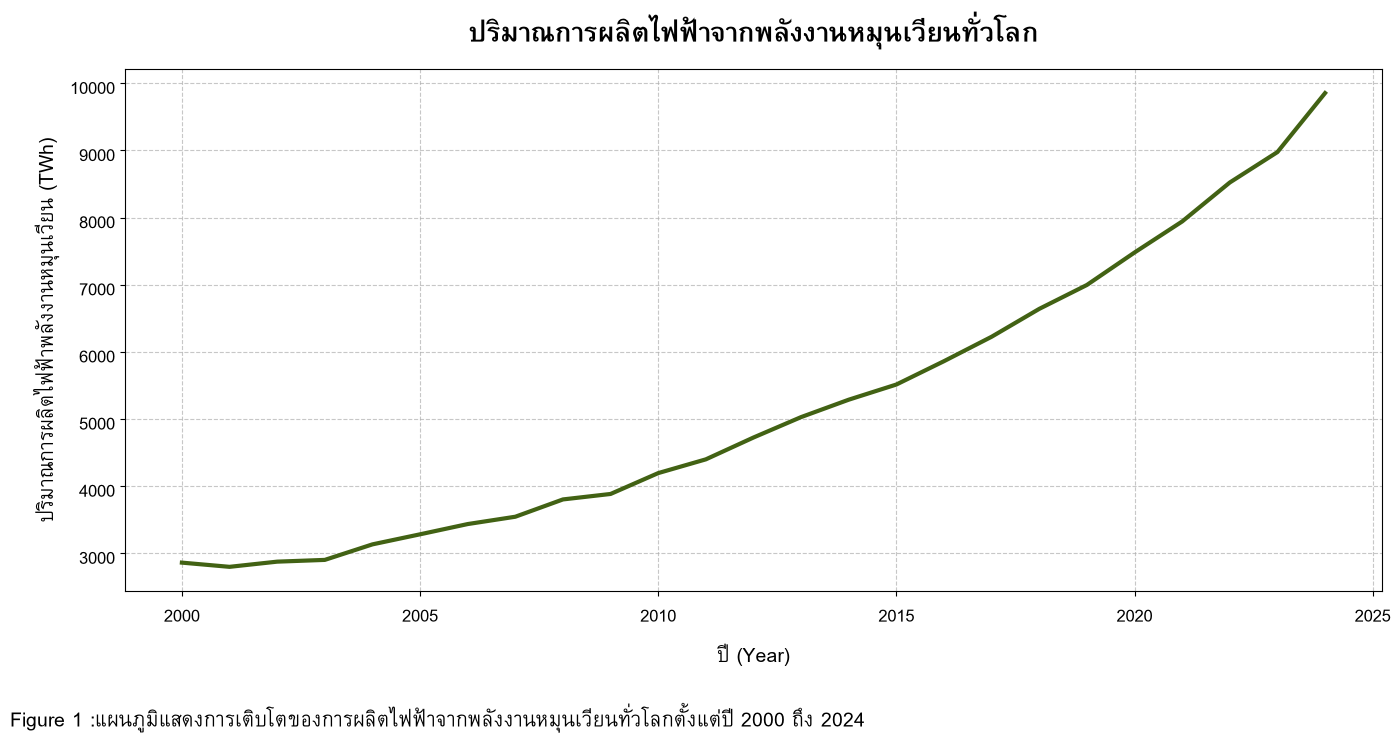

In [149]:
df_filtered = df[df['year'] < 2025]
df_filtered['renewable_electricity_TWh'] = df_filtered['electricity_generation'] * (df_filtered['renewables_share_elec'] / 100)

global_renewable_generation = df_filtered.groupby('year')['renewable_electricity_TWh'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='year', y='renewable_electricity_TWh', data=global_renewable_generation, color='#426214', linewidth=3)

plt.title('ปริมาณการผลิตไฟฟ้าจากพลังงานหมุนเวียนทั่วโลก',fontweight='bold', fontsize=18, pad=20)
plt.xlabel('ปี (Year)', fontsize=14)
plt.ylabel('ปริมาณการผลิตไฟฟ้าพลังงานหมุนเวียน (TWh)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.locator_params(axis='x', nbins=10)

# Adding description text below the plot
description_text = 'Figure 1 :แผนภูมิแสดงการเติบโตของการผลิตไฟฟ้าจากพลังงานหมุนเวียนทั่วโลกตั้งแต่ปี 2000 ถึง 2024'
plt.figtext(0, -0.05, description_text, wrap=True, horizontalalignment='left', fontsize=14, color='black')

plt.tight_layout()
plt.show()

#Figure 2

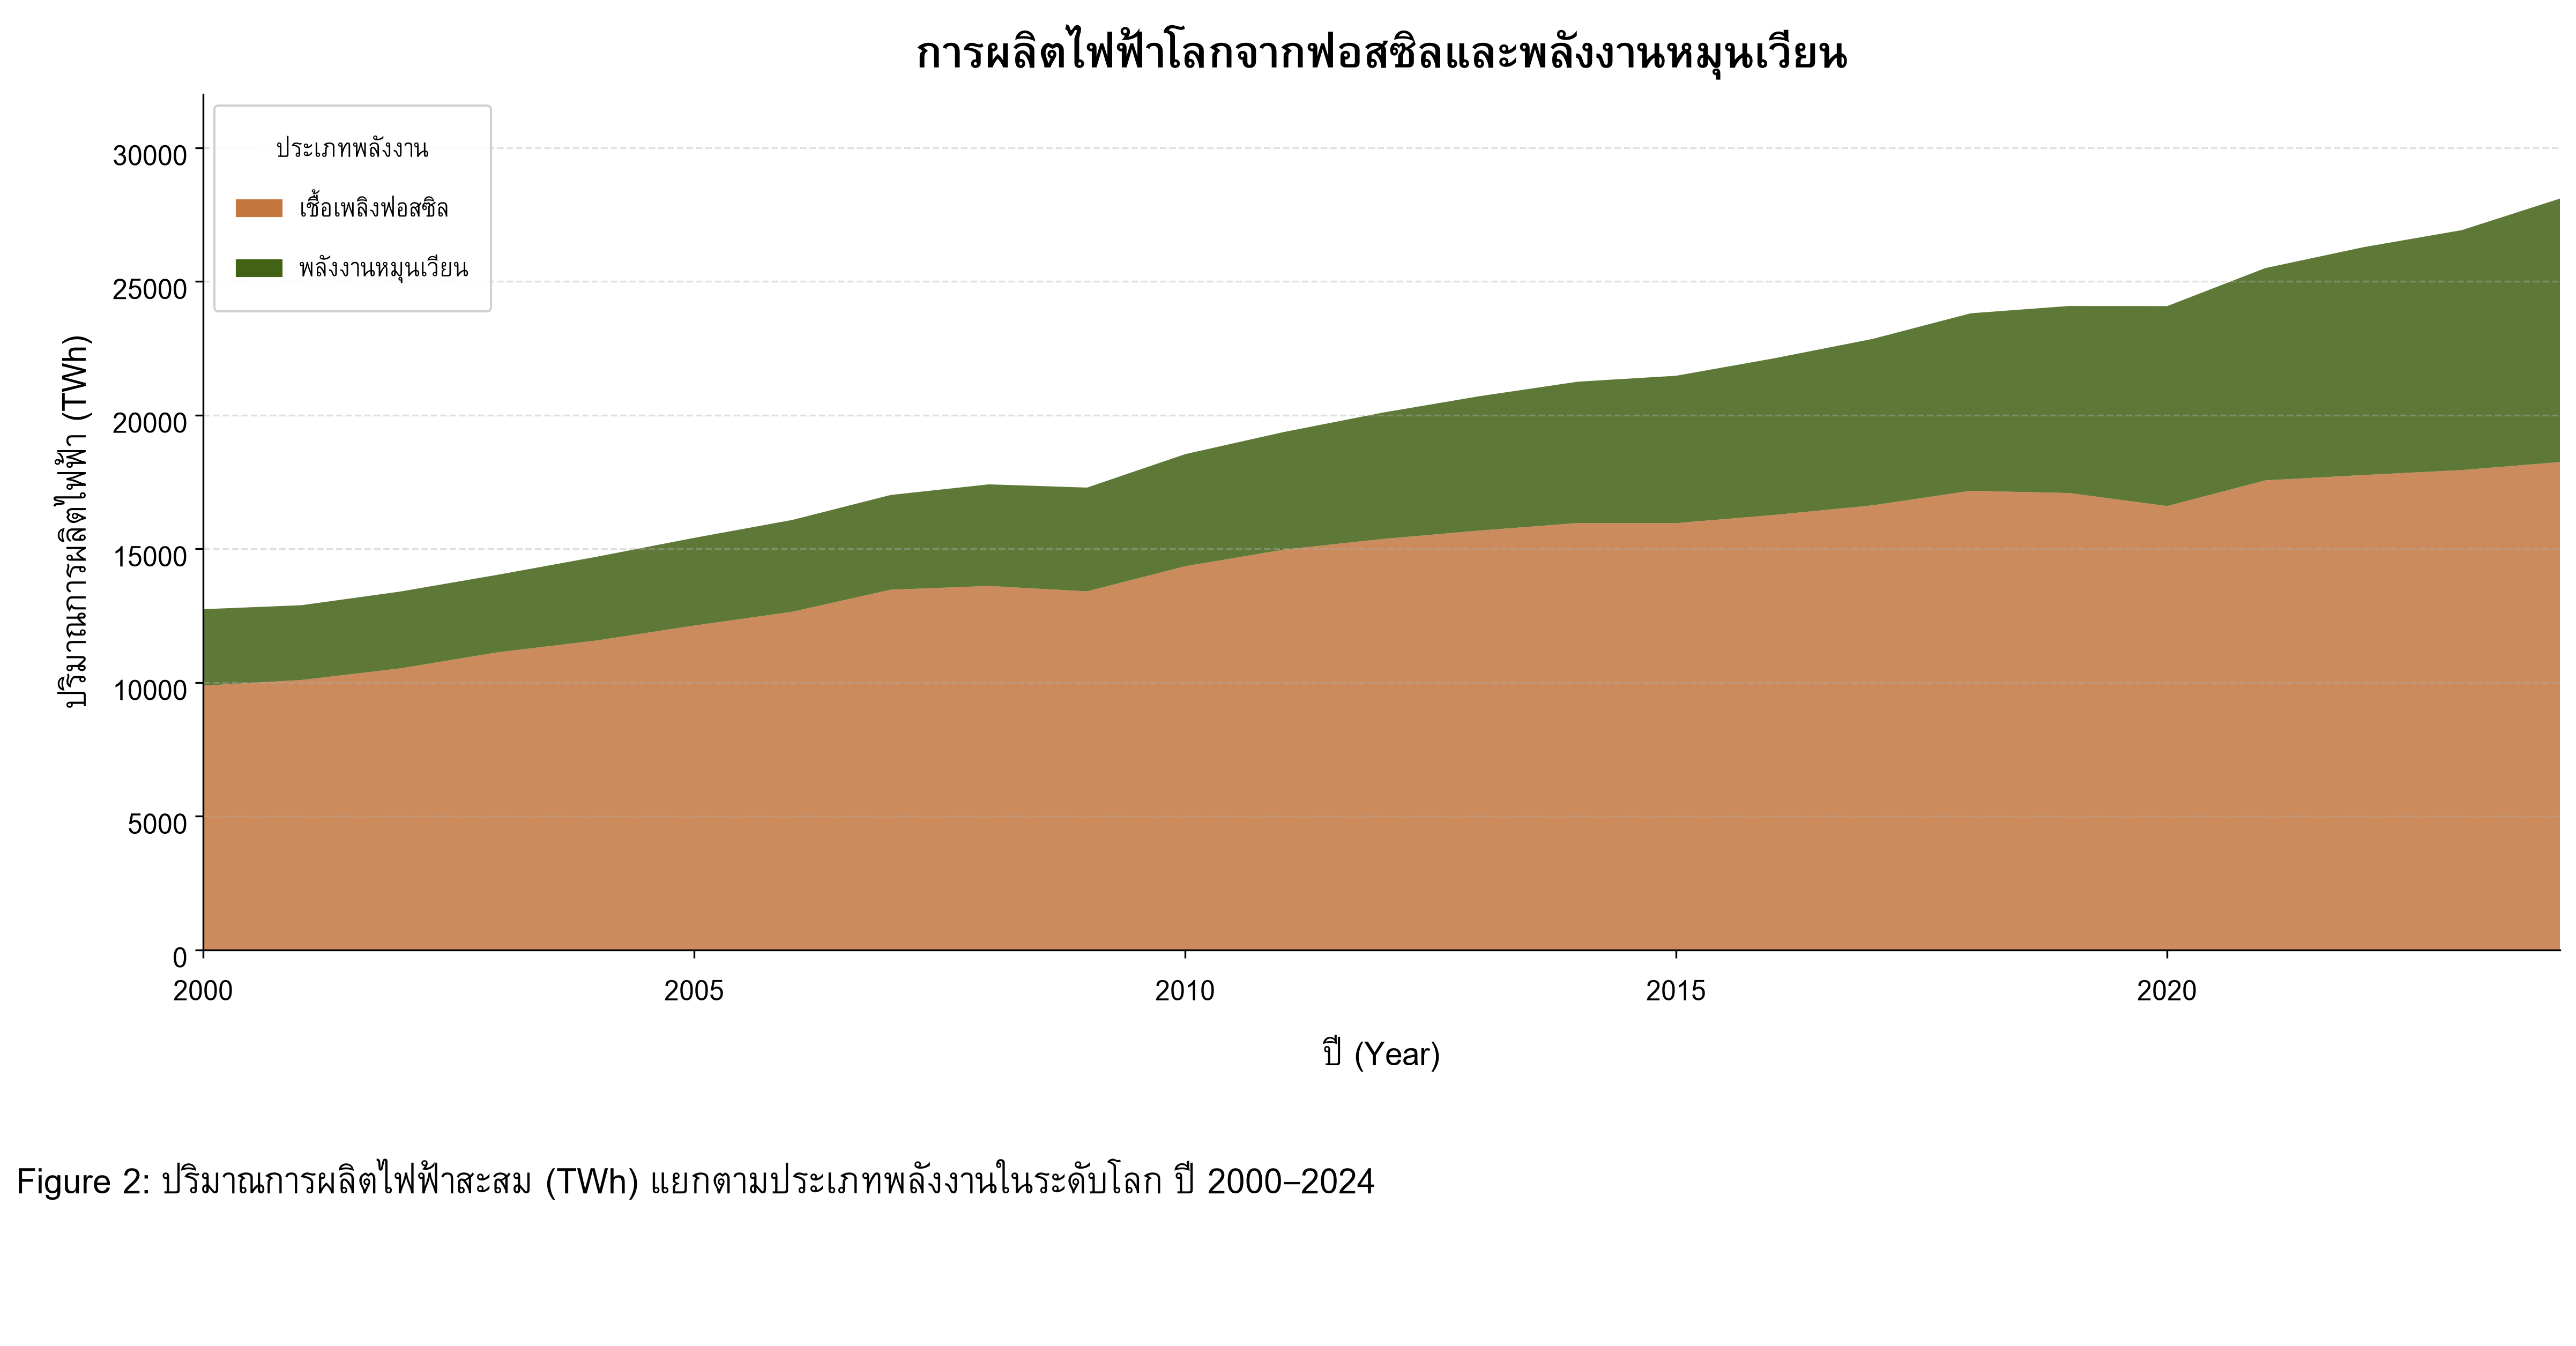

In [150]:
world = df.groupby('year').agg(
    fossil  = ('coal_electricity',  'sum'),
    gas     = ('gas_electricity',   'sum'),
    oil     = ('oil_electricity',   'sum'),
    solar   = ('solar_electricity', 'sum'),
    wind    = ('wind_electricity',  'sum'),
    hydro   = ('hydro_electricity', 'sum'),
    other_re= ('other_renewable_electricity', 'sum'),
).reset_index()

world['Fossil']  = world['fossil'] + world['gas'] + world['oil']
world['RE']      = world['solar'] + world['wind'] + world['hydro'] + world['other_re']

C_RE='#426214'; C_FOSSIL='#C3773F'

fig, ax1 = plt.subplots(figsize=(16, 7), dpi=300, facecolor='white')

# ── Stacked Area ──────────────────────────────────────────────
ax1.stackplot(world['year'], world['Fossil'], world['RE'],
              colors=[C_FOSSIL, C_RE], alpha=0.85)
ax1.set_xlim(2000, 2024)
ax1.set_ylim(0, 32000)

# label แกน
ax1.set_xlabel('ปี (Year)', fontsize=14)
ax1.set_ylabel('ปริมาณการผลิตไฟฟ้า (TWh)', fontsize=14)
ax1.set_title('การผลิตไฟฟ้าโลกจากฟอสซิลและพลังงานหมุนเวียน',
              fontsize=18, fontweight='bold', pad=12)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.spines[['top','right']].set_visible(False)

# กำกับชื่อตามสีบนกราฟ

legend_items = [
    (C_FOSSIL,  'เชื้อเพลิงฟอสซิล'),
    (C_RE,      'พลังงานหมุนเวียน'),
]
handles = [mpatches.Patch(color=c, label=l) for c, l in legend_items]
ax1.legend(
    handles=handles,
    title='ประเภทพลังงาน',
    title_fontsize=10,
    fontsize=10,
    loc='upper left',
    framealpha=0.9,
    edgecolor='#cccccc',
    borderpad=1.0,
    labelspacing=0.8,
)

# คำอธิบายใต้กราฟ
caption = (
    "Figure 2: ปริมาณการผลิตไฟฟ้าสะสม (TWh) แยกตามประเภทพลังงานในระดับโลก ปี 2000–2024\n"
)
fig.text(0, -0.015, caption,
         ha='left', va='top', fontsize=15,
         color="#030303", linespacing=1.6)

plt.tight_layout()
plt.savefig('figure3_stackedarea.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#Figure 3

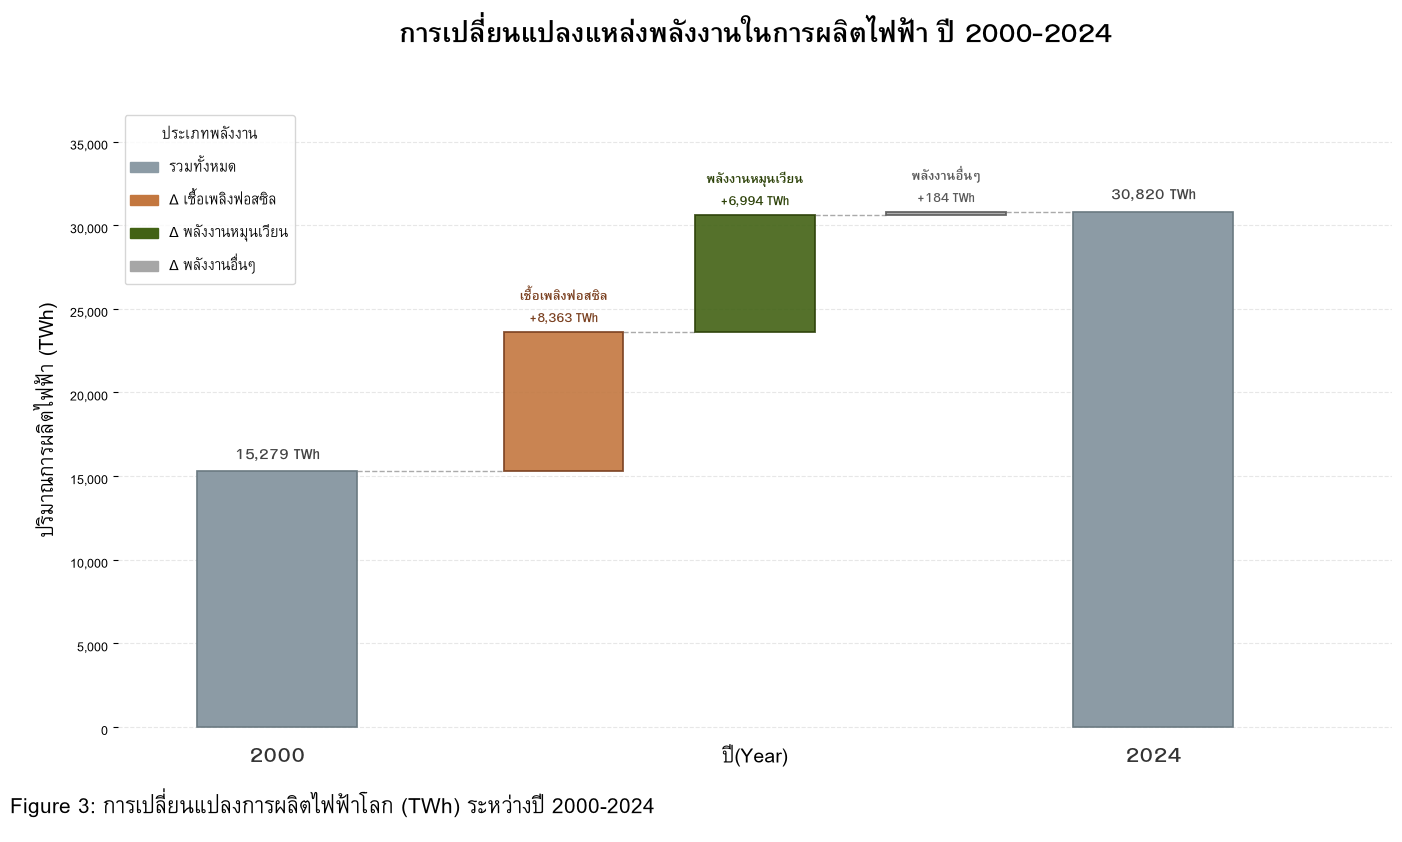

In [151]:
world = df.groupby('year').agg(
    coal     = ('coal_electricity',            'sum'),
    gas      = ('gas_electricity',             'sum'),
    oil      = ('oil_electricity',             'sum'),
    solar    = ('solar_electricity',           'sum'),
    wind     = ('wind_electricity',            'sum'),
    hydro    = ('hydro_electricity',           'sum'),
    other_re = ('other_renewable_electricity', 'sum'),
    Other    = ('nuclear_electricity', 'sum'),  # แสดงเป็นพลังงานอื่นๆ ตามที่กำหนด
).reset_index()

world['Fossil']  = world['coal'] + world['gas'] + world['oil']
world['RE']      = world['solar'] + world['wind'] + world['hydro'] + world['other_re']

# ── ส่วนที่ 2: คำนวณค่า 2000, 2024 และ Δ ────────────────────
y2000 = world[world.year == 2000].iloc[0]
y2024 = world[world.year == 2024].iloc[0]

sources    = ['Fossil', 'RE', 'Other']
val2000    = {s: y2000[s] for s in sources}
val2024    = {s: y2024[s] for s in sources}
delta      = {s: val2024[s] - val2000[s] for s in sources}
total_2000 = sum(val2000.values())
total_2024 = sum(val2024.values())
th_name = {
    'Fossil':  'เชื้อเพลิงฟอสซิล',
    'RE':      'พลังงานหมุนเวียน',
    'Other':   'พลังงานอื่นๆ',
}

# ── ส่วนที่ 3: กำหนดสี ───────────────────────────────────────
C_BAR  = '#8C9BA5'
C_src  = {'Fossil': '#C3773F', 'RE': '#426214', 'Other': '#A6A6A6'}
C_dark = {'Fossil': '#7a4020', 'RE': '#2d4209', 'Other': '#595959'}

# ── ส่วนที่ 4: ตำแหน่งแกน X ──────────────────────────────────
x_left   = 1.0
x_right  = 6.5
bw       = 1.0    # ความกว้างแท่งหลัก
dw       = 0.75   # ความกว้างแท่ง Δ
x_deltas = {'Fossil': 2.8, 'RE': 4.0, 'Other': 5.2}

# ── ส่วนที่ 5: วาดกราฟ ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
ax.set_facecolor('white')
fig.subplots_adjust(bottom=0.12)

# แท่งรวม 2000 & 2024 (สีเดียว ไม่แยก source)
ax.bar(x_left,  total_2000, width=bw, color=C_BAR,
       edgecolor='#6b7a82', linewidth=1.2, zorder=3)
ax.bar(x_right, total_2024, width=bw, color=C_BAR,
       edgecolor='#6b7a82', linewidth=1.2, zorder=3)

# label ยอดรวม
ax.text(x_left,  total_2000 + 250, f'{total_2000:,.0f} TWh',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#444')
ax.text(x_right, total_2024 + 250, f'{total_2024:,.0f} TWh',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#444')

# label ปี
ax.text(x_left,  -600, '2000', ha='center', va='top',
        fontsize=14, fontweight='bold', color='#333')
ax.text(x_right, -600, '2024', ha='center', va='top',
        fontsize=14, fontweight='bold', color='#333')

# ── ส่วนที่ 6: Waterfall Δ bars (cascade) ────────────────────
# แต่ละแท่งเริ่มต้นที่ปลายของแท่งก่อนหน้า
# เริ่มจากยอดรวมปี 2000
running_bottom = total_2000

for s in sources:
    d  = delta[s]
    xd = x_deltas[s]

    if d >= 0:
        bar_bot = running_bottom
        bar_top = running_bottom + d
    else:
        bar_bot = running_bottom + d
        bar_top = running_bottom

    # วาดแท่ง Δ
    ax.bar(xd, abs(d), bottom=bar_bot, width=dw,
           color=C_src[s], alpha=0.90,
           edgecolor=C_dark[s], linewidth=1.3, zorder=4)

    # label บนแท่ง
    sign = '+' if d >= 0 else ''
    ax.text(xd, bar_top + 150,
            f'{th_name[s]}\n{sign}{d:,.0f} TWh',
            ha='center', va='bottom', fontsize=8.5,
            fontweight='bold', color=C_dark[s], zorder=6)

    # เส้นประเชื่อมแท่งถัดไป (ที่ระดับ bar_top)
    next_sources = sources[sources.index(s)+1:]
    if next_sources:
        xd_next = x_deltas[next_sources[0]]
        ax.plot([xd + dw/2, xd_next - dw/2],
                [running_bottom + d, running_bottom + d],
                color='#aaaaaa', lw=1.0, ls='--', zorder=2)

    running_bottom += d  # อัปเดตจุดเริ่มต้นของแท่งถัดไป

# เส้นประ: ยอด 2000 → Fossil
ax.plot([x_left + bw/2, x_deltas['Fossil'] - dw/2],
        [total_2000, total_2000],
        color='#aaaaaa', lw=1.0, ls='--', zorder=2)

ax.plot([x_deltas['Other'] + dw/2, x_right - bw/2],
        [total_2024, total_2024],
        color='#aaaaaa', lw=1.0, ls='--', zorder=2)

# ── ส่วนที่ 7: ตกแต่ง Axes ───────────────────────────────────
y_max = total_2024 * 1.20
ax.set_xlim(0, x_right + bw + 0.5)
ax.set_ylim(-300, y_max)
ax.set_yticks(np.arange(0, y_max, 5000))
ax.set_yticklabels([f'{int(v):,}' for v in np.arange(0, y_max, 5000)], fontsize=9)
ax.set_ylabel('ปริมาณการผลิตไฟฟ้า (TWh)', fontsize=14)
ax.set_xlabel('ปี(Year)', fontsize=14)
ax.set_title('การเปลี่ยนแปลงแหล่งพลังงานในการผลิตไฟฟ้า ปี 2000-2024\n',
    fontsize=18,fontweight='bold',pad=14 )
ax.set_xticks([])
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

## ── ส่วนที่ 8: Legend ─────────────────────────────────────────
handles = [mpatches.Patch(color=C_BAR, label='รวมทั้งหมด')]
handles += [mpatches.Patch(color=C_src[s], label=f'$\\Delta$ {th_name[s]}') for s in sources]
ax.legend(handles=handles, loc='upper left', fontsize=10,
          framealpha=0.8, title='ประเภทพลังงาน', title_fontsize=10)

# ── ส่วนที่ 9: Figure Caption ─────────────────────────────────
caption = (
    "Figure 3: การเปลี่ยนแปลงการผลิตไฟฟ้าโลก (TWh) ระหว่างปี 2000-2024 "
)
fig.text(0,-0.05, caption,
         ha='left', va='bottom',
         fontsize=15, color="#010101",
         linespacing=1.5)

plt.tight_layout()
plt.savefig('figure4_waterfall.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#Table 1

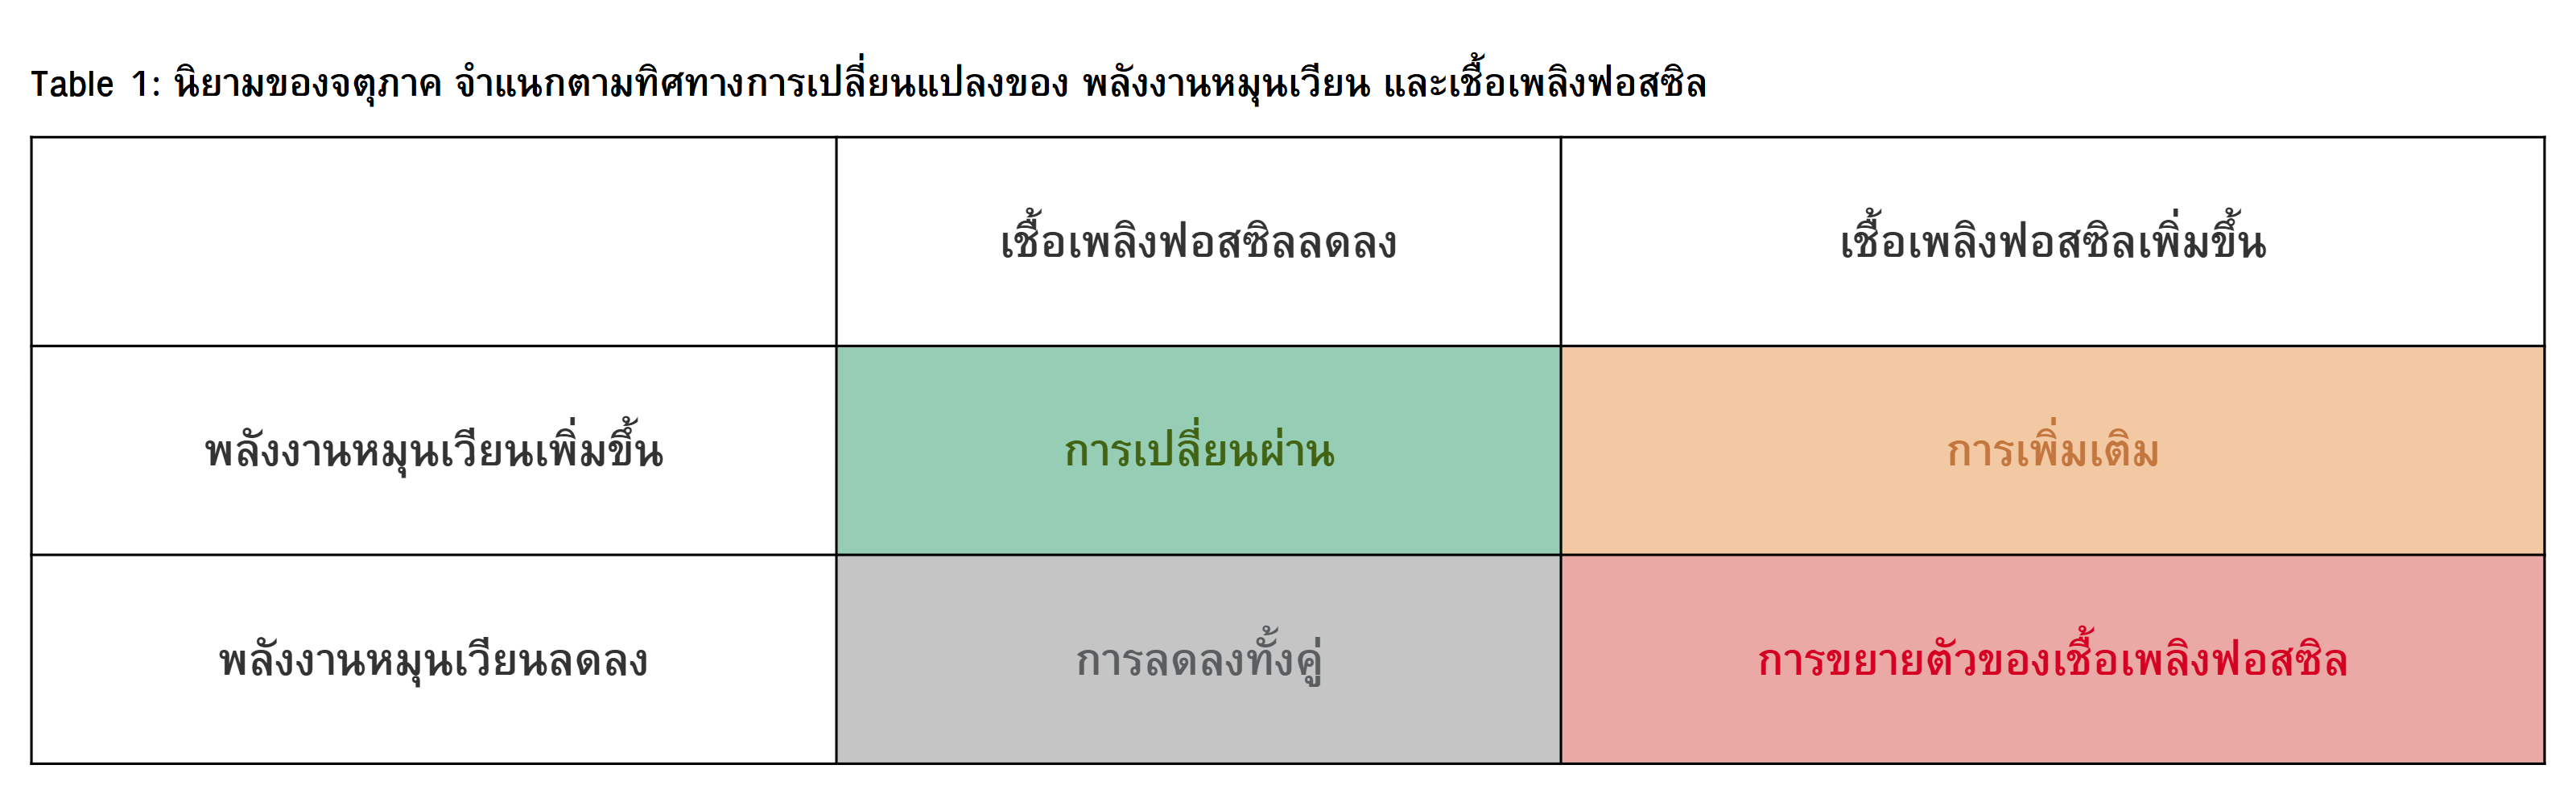

In [152]:
from pathlib import Path
import sys
from IPython.display import Image, display
import pandas as pd
_table_dir = next(p for p in [Path.cwd(), Path.cwd() / 'dads 5001']
                  if (p / 'export_table_image.py').is_file())
if str(_table_dir) not in sys.path:
    sys.path.insert(0, str(_table_dir))
from export_table_image import export_table

# Explicit header and two data rows prevent an empty index-name row.
table1_html = """
<style>
#table1 {border-collapse: collapse; font-family: Garuda, sans-serif; font-size: 16px; width: 1000px; max-width: 100%;}
#table1 th, #table1 td {border: 1px solid #000000; padding: 26px 28px; text-align: center; font-weight: bold;}
#table1 thead th {background: #ffffff; color: #333333;}
#table1 tbody th {background: #ffffff; color: #333333; white-space: nowrap;}
#table1 tbody td {white-space: normal; min-width: 150px; height: 20px;}
</style>
<table id="table1">
<caption style="caption-side: top; text-align: left; font-size: 14px;font-weight: bold; padding: 10px 0; line-height: 1.6;">Table 1: นิยามของจตุภาค จำแนกตามทิศทางการเปลี่ยนแปลงของ\n
 พลังงานหมุนเวียน และเชื้อเพลิงฟอสซิล</caption>
<thead><tr><th></th><th> เชื้อเพลิงฟอสซิลลดลง </th><th>เชื้อเพลิงฟอสซิลเพิ่มขึ้น</th></tr></thead>
<tbody>
<tr><th>พลังงานหมุนเวียนเพิ่มขึ้น</th><td style="color: #426214; background-color: color-mix(in srgb, #2E9E6B 50%, transparent);">การเปลี่ยนผ่าน</td><td style="color: #C3773F; background-color: color-mix(in srgb, #E8934A 50%, transparent);">การเพิ่มเติม</td></tr>
<tr><th>พลังงานหมุนเวียนลดลง</th><td style="color: #5A5E60; background-color: color-mix(in srgb, #8C8C8C 50%, transparent);">การลดลงทั้งคู่</td><td style="color: #D40123; background-color: color-mix(in srgb, #D6534A 50%, transparent);">การขยายตัวของเชื้อเพลิงฟอสซิล</td></tr>
</tbody>
</table>
"""
table1_path = export_table(table1_html, 'table1', width=1100)
display(Image(filename=str(table1_path), width=1000))


#Table2

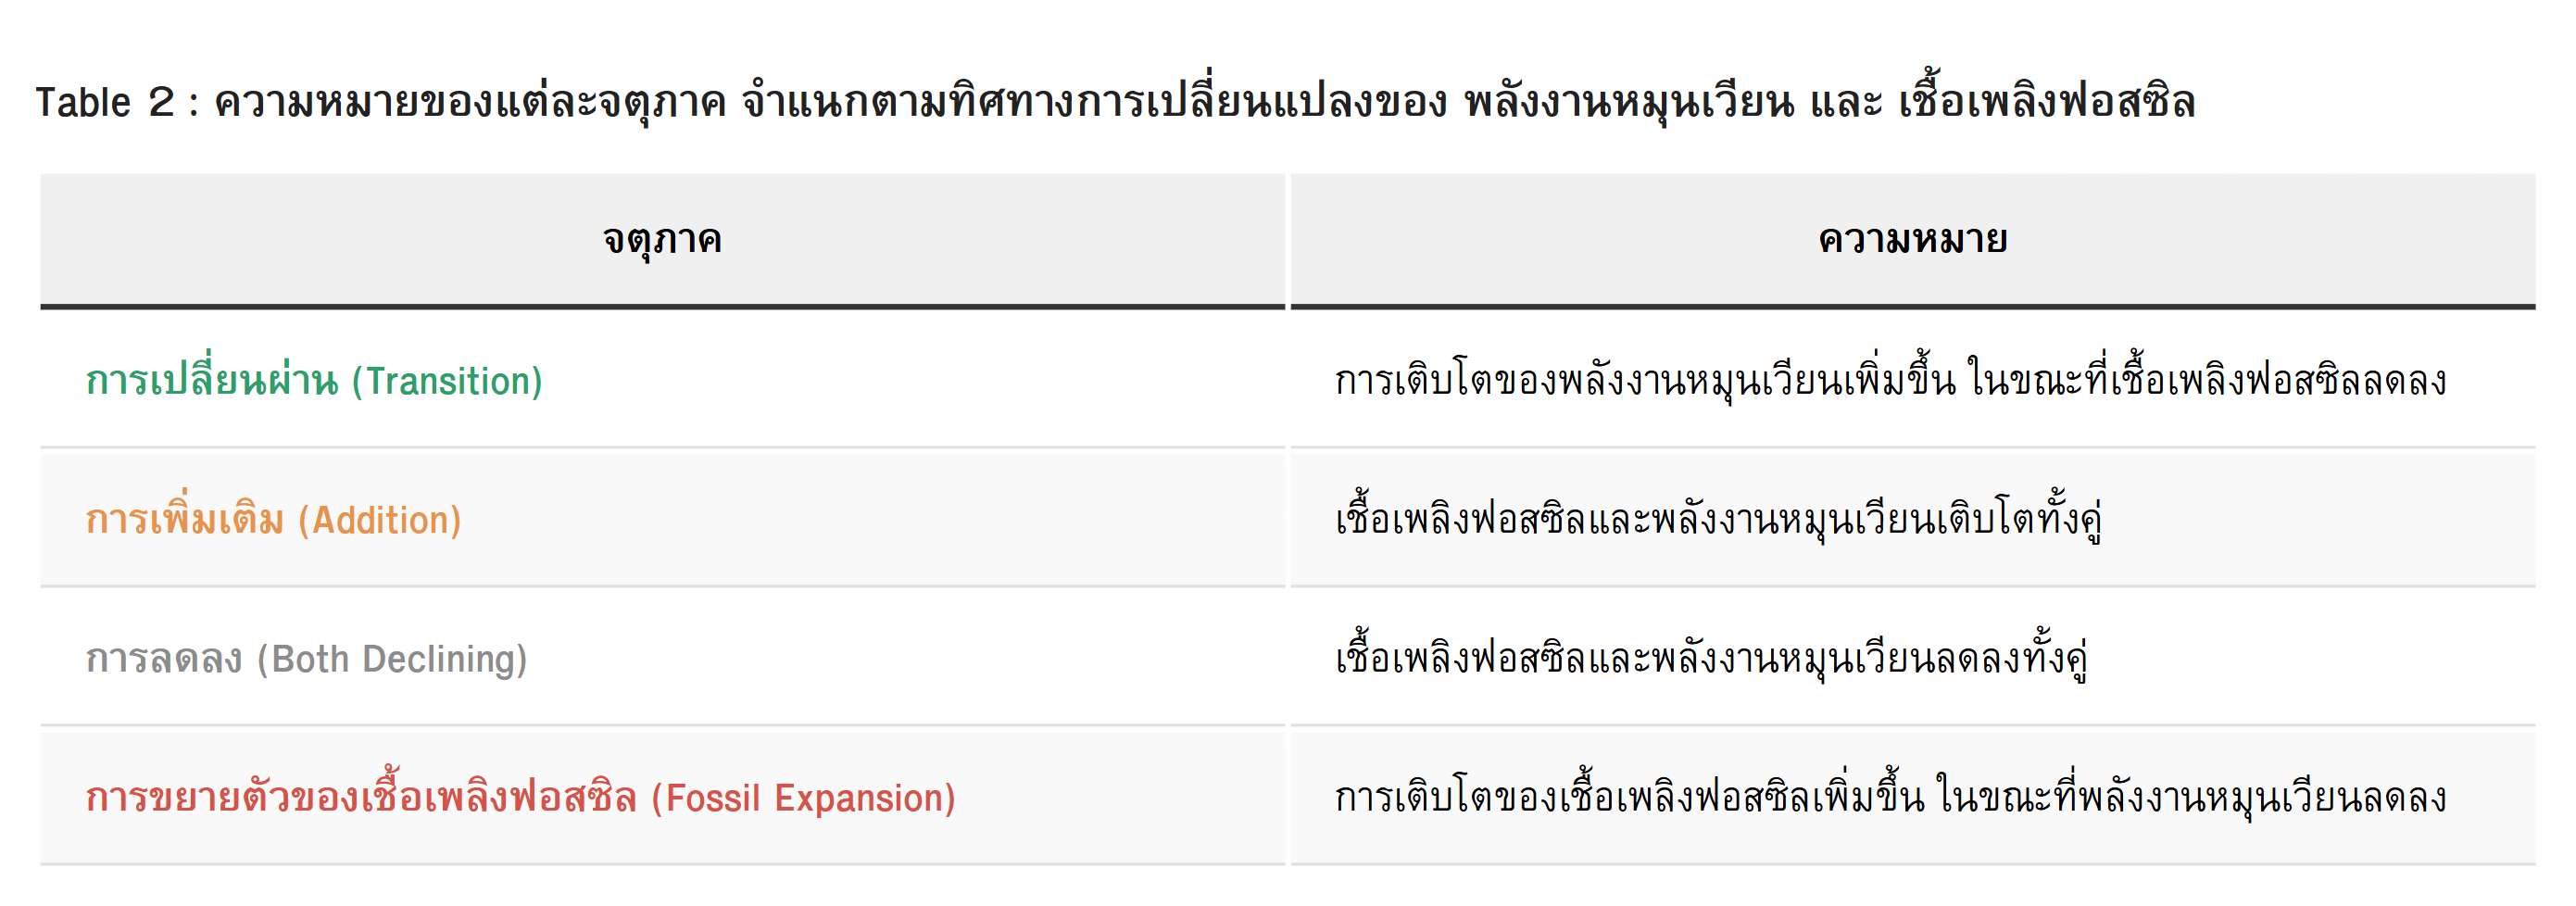

In [153]:
from pathlib import Path
import sys
from IPython.display import Image, display
import pandas as pd
_table_dir = next(p for p in [Path.cwd(), Path.cwd() / 'dads 5001']
                  if (p / 'export_table_image.py').is_file())
if str(_table_dir) not in sys.path:
    sys.path.insert(0, str(_table_dir))
from export_table_image import export_table

# ── ข้อมูลตาราง ───────────────────────────────────────────────
data = {
    'จตุภาค': [
        'การเปลี่ยนผ่าน (Transition)',
        'การเพิ่มเติม (Addition)',
        'การลดลง (Both Declining)',
        'การขยายตัวของเชื้อเพลิงฟอสซิล (Fossil Expansion)',
    ],
    'ความหมาย': [
        'การเติบโตของพลังงานหมุนเวียนเพิ่มขึ้น ในขณะที่เชื้อเพลิงฟอสซิลลดลง',
        'เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียนเติบโตทั้งคู่',
        'เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียนลดลงทั้งคู่',
        'การเติบโตของเชื้อเพลิงฟอสซิลเพิ่มขึ้น ในขณะที่พลังงานหมุนเวียนลดลง',
    ],
}

df_table = pd.DataFrame(data)

# ── สีแต่ละแถว ────────────────────────────────────────────────
ROW_COLORS = {
    0: '#2E9E6B',
    1: '#E8934A',
    2: "#8C8C8C",
    3: '#D6534A',

}

styled = (
    df_table.style
    .apply(lambda row: [
        f'color: {ROW_COLORS[row.name]}; font-weight: bold',
        '',
    ], axis=1)
    .set_properties(**{
        'font-family': 'Garuda',
        'font-size': '13px',
        'padding': '10px 15px',
        'text-align': 'left',
        'border-bottom': '1px solid #e0e0e0',
    })
    .set_table_styles([
        {'selector': 'thead th', 'props': [
            ('background-color', '#f0f0f0'),
            ('font-weight', 'bold'),
            ('font-size', '13px'),
            ('padding', '10px 15px'),
            ('border-bottom', '2px solid #333'),
            ('text-align', 'center'),    
            ('word-wrap', 'break-word'), 
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#f9f9f9'),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', '#f0f0f0'),
        ]},
        {'selector': 'caption', 'props': [
            ('font-weight', 'bold'),
            ('font-size', '14px'),
            ('padding', '10px 0'),
            ('text-align', 'left'),
            ('color', '#222'),
        ]},
        {'selector': 'th:nth-child(1), td:nth-child(1)', 'props': [
            ('width', '400px'), ('min-width', '220px'),
        ]},
        {'selector': 'th:nth-child(2), td:nth-child(2)', 'props': [
            ('width', '400px'), ('min-width', '400px'),
        ]},
    ])
    .set_caption('Table 2 : ความหมายของแต่ละจตุภาค จำแนกตามทิศทางการเปลี่ยนแปลงของ พลังงานหมุนเวียน และ เชื้อเพลิงฟอสซิล')
    .hide(axis='index')
)

table2_path = export_table(styled.to_html(), 'table2', width=1100)
display(Image(filename=str(table2_path), width=900))

#Figure 4

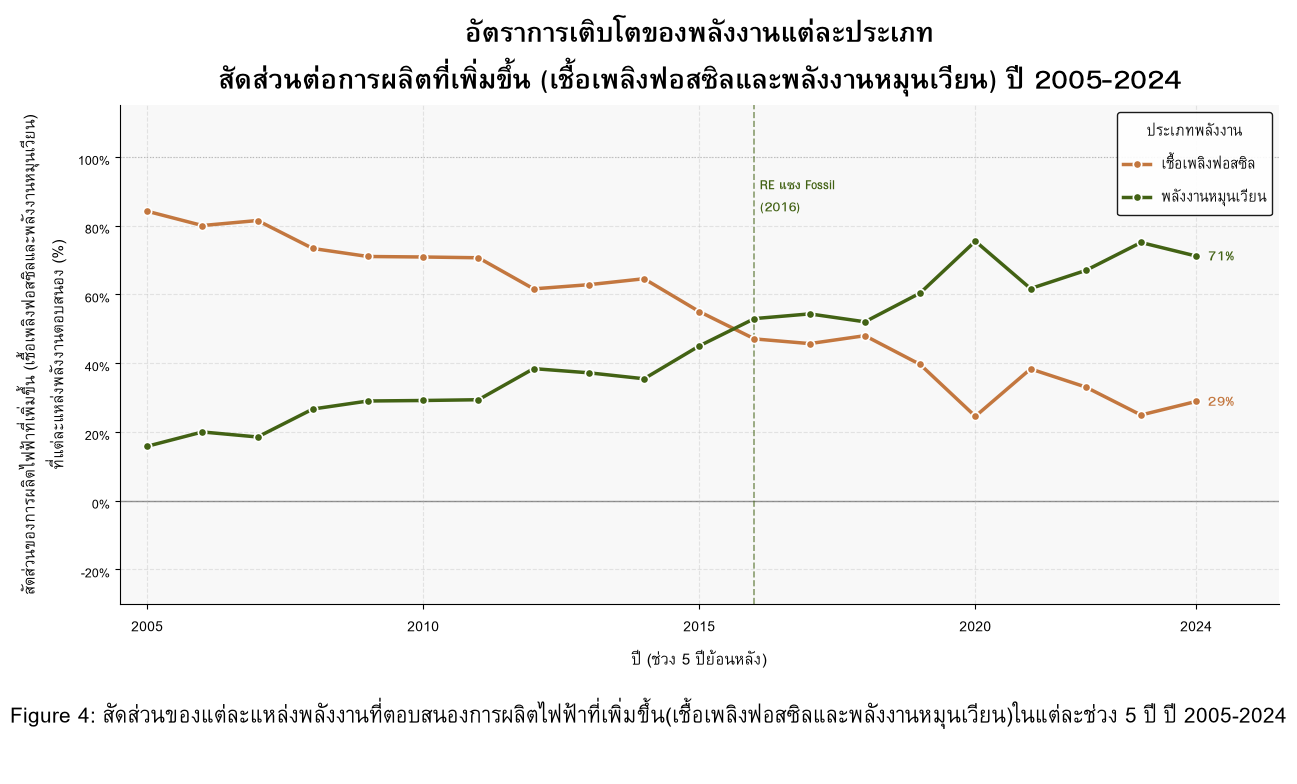

In [154]:

world = df.groupby('year').agg(
    coal     = ('coal_electricity',            'sum'),
    gas      = ('gas_electricity',             'sum'),
    oil      = ('oil_electricity',             'sum'),
    solar    = ('solar_electricity',           'sum'),
    wind     = ('wind_electricity',            'sum'),
    hydro    = ('hydro_electricity',           'sum'),
    other_re = ('other_renewable_electricity', 'sum'),
).reset_index()

world['Fossil']  = world['coal'] + world['gas'] + world['oil']
world['RE']      = world['solar'] + world['wind'] + world['hydro'] + world['other_re']
world['Total']   = world['Fossil'] + world['RE']

world = world[world['year'].between(2000, 2024)].reset_index(drop=True)
world = world.set_index('year')

# ── คำนวณ 5-year rolling share ───────────────────────────────
results = []
for y in range(2005, 2025):
    if y-5 not in world.index or y not in world.index:
        continue
    d_total   = world.loc[y, 'Total']   - world.loc[y-5, 'Total']
    d_fossil  = world.loc[y, 'Fossil']  - world.loc[y-5, 'Fossil']
    d_re      = world.loc[y, 'RE']      - world.loc[y-5, 'RE']
    if d_total == 0:
        continue
    results.append({
        'year':    y,
        'Fossil':  d_fossil  / d_total * 100,
        'RE':      d_re      / d_total * 100,
    })

roll = pd.DataFrame(results)

# ── สี ────────────────────────────────────────────────────────
C_FOSSIL  = '#C3773F'
C_RE      = '#426214'

# ── Figure ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7), facecolor='white')
ax.set_facecolor('#f8f8f8')

# เส้น reference
ax.axhline(100, color='#bbbbbb', lw=0.8, ls=':', zorder=1)
ax.axhline(0,   color='#888888', lw=1.0, ls='-', zorder=1)

# วาด 2 เส้น
for col, color, label in [
    ('Fossil',  C_FOSSIL,  'เชื้อเพลิงฟอสซิล'),
    ('RE',      C_RE,      'พลังงานหมุนเวียน'),
]:
    ax.plot(roll['year'], roll[col],
            color=color, lw=2.5, marker='o',
            markersize=6, markerfacecolor=color,
            markeredgecolor='white', markeredgewidth=1.2,
            label=label, zorder=4)

    # label ปลายเส้น
    last = roll.iloc[-1]
    ax.text(last['year'] + 0.2, last[col],
            f"{last[col]:.0f}%",
            fontsize=9, color=color, fontweight='bold',
            va='center', zorder=5)

# จุดที่ RE แซง Fossil
cross_year = None
for i in range(len(roll)-1):
    if roll.iloc[i]['RE'] < roll.iloc[i]['Fossil'] and \
       roll.iloc[i+1]['RE'] >= roll.iloc[i+1]['Fossil']:
        cross_year = roll.iloc[i+1]['year']
        break

if cross_year:
    ax.axvline(cross_year, color='#426214', lw=1.2,
               ls='--', alpha=0.6, zorder=2)
    ax.text(cross_year + 0.1, 95,
            f'RE แซง Fossil\n({cross_year:.0f})',
            fontsize=8.5, color='#426214',
            va='top', fontweight='bold')

# ── Axes ──────────────────────────────────────────────────────
ax.set_xlim(2004.5, 2025.5)
ax.set_ylim(-30, 115)

# แกน x ทีละ 5 ปี
ax.set_xticks([2005, 2010, 2015, 2020, 2024])
ax.set_xticklabels(['2005', '2010', '2015', '2020', '2024'], fontsize=10)

ax.set_yticks(range(-20, 120, 20))
ax.set_yticklabels([f'{v}%' for v in range(-20, 120, 20)], fontsize=9)

ax.set_xlabel('ปี (ช่วง 5 ปีย้อนหลัง)', fontsize=11)
ax.set_ylabel('สัดส่วนของการผลิตไฟฟ้าที่เพิ่มขึ้น (เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน)\nที่แต่ละแหล่งพลังงานตอบสนอง (%)', fontsize=11)
ax.set_title('อัตราการเติบโตของพลังงานแต่ละประเภท\n'
             'สัดส่วนต่อการผลิตที่เพิ่มขึ้น (เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน) ปี 2005-2024',
             fontsize=18,fontweight='bold', pad=12)

ax.grid(axis='both', linestyle='--', alpha=0.3, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

# Legend
ax.legend(loc='upper right', fontsize=10, framealpha=0.9,
          edgecolor="#010101",
          title='ประเภทพลังงาน', title_fontsize=10)

# Caption
fig.text(0.01, -0.1,
         'Figure 4: สัดส่วนของแต่ละแหล่งพลังงานที่ตอบสนองการผลิตไฟฟ้าที่เพิ่มขึ้น(เชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน)ในแต่ละช่วง 5 ปี ปี 2005-2024\n',
         ha='left', fontsize=15, color='black')

plt.tight_layout()
plt.savefig('figure4_momentum.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#figure 5

จำนวนประเทศทั้งหมด: 194
quadrant
การเพิ่มเติม                     133
การเปลี่ยนผ่าน                    53
การขยายตัวของเชื้อเพลิงฟอสซิล      8
Name: count, dtype: int64
ประเทศที่แสดงชื่อ:
           country                       quadrant  gen_2024
139       Paraguay  การขยายตัวของเชื้อเพลิงฟอสซิล     42.41
171          Syria  การขยายตัวของเชื้อเพลิงฟอสซิล     24.88
44            Cuba  การขยายตัวของเชื้อเพลิงฟอสซิล     19.43
187  United States                 การเปลี่ยนผ่าน   4391.02
32          Canada                 การเปลี่ยนผ่าน    636.79
61          France                 การเปลี่ยนผ่าน    561.78
37           China                   การเพิ่มเติม  10086.88
82           India                   การเพิ่มเติม   2036.52
147         Russia                   การเพิ่มเติม   1209.31
175       Thailand                   การเพิ่มเติม    199.52
saved


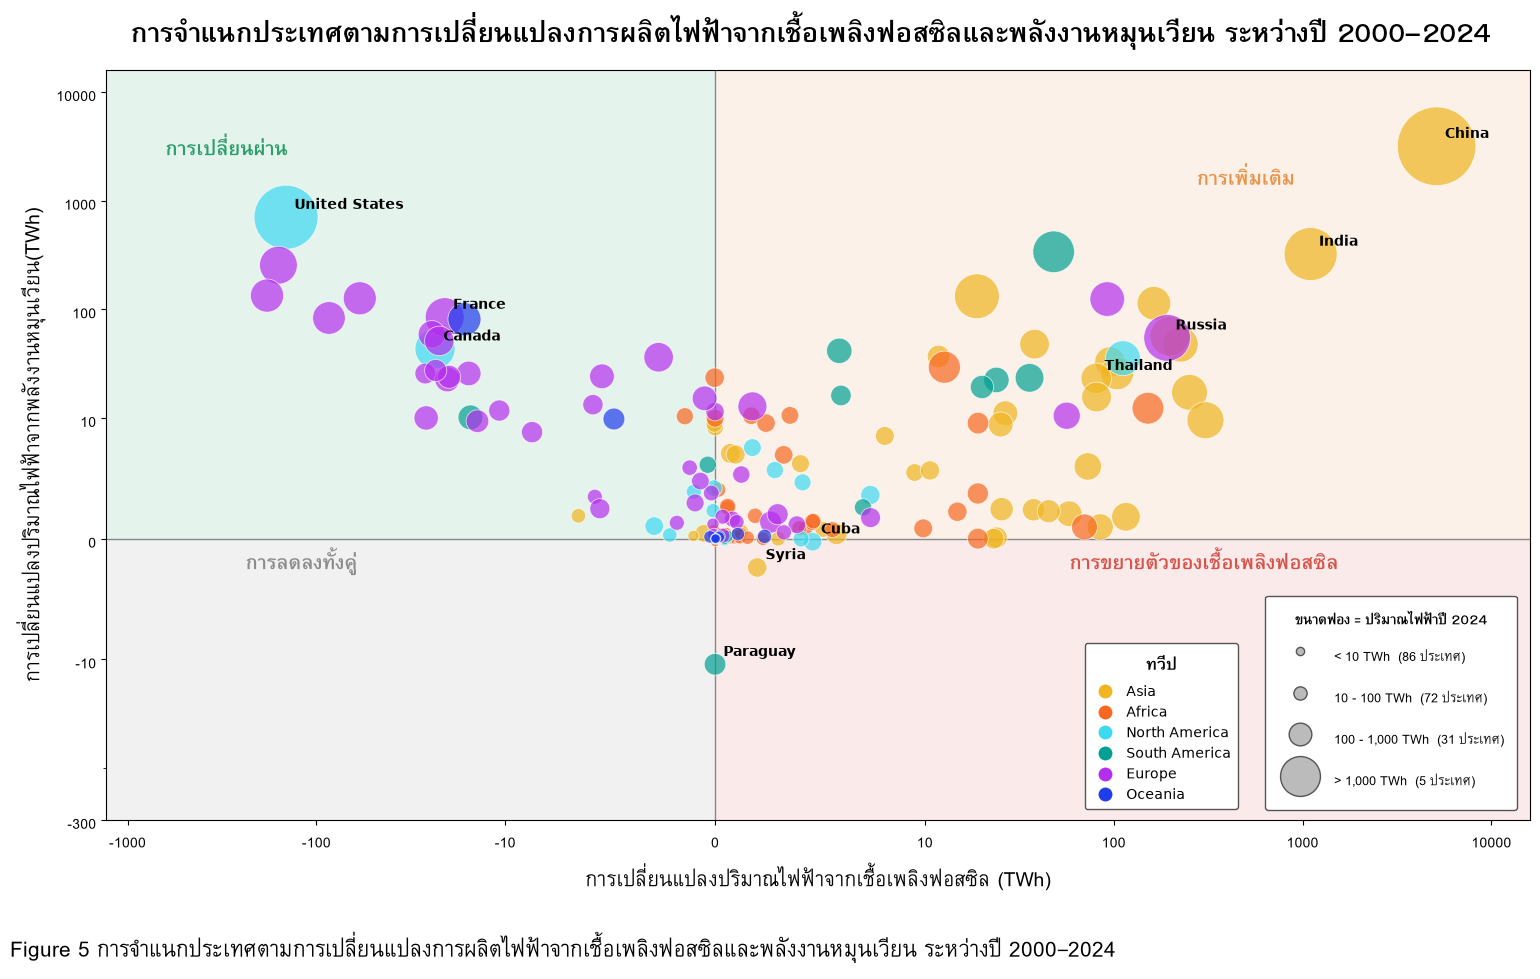

In [155]:

df = df.copy()

df['fossil'] = df['coal_electricity'] + df['gas_electricity'] + df['oil_electricity']
df['renewables'] = (df['hydro_electricity'] + df['solar_electricity']
                     + df['wind_electricity'] + df['other_renewable_electricity'])

p0 = df[df.year == 2000][['country', 'iso_code', 'continent', 'fossil', 'renewables', 'electricity_generation']] \
        .rename(columns={'fossil': 'fossil_2000', 'renewables': 'ren_2000'})
p1 = df[df.year == 2024][['country', 'fossil', 'renewables', 'electricity_generation']] \
        .rename(columns={'fossil': 'fossil_2024', 'renewables': 'ren_2024',
                          'electricity_generation': 'gen_2024'})

m = p0.merge(p1, on='country').dropna(subset=['electricity_generation', 'gen_2024'])

m['delta_fossil'] = m['fossil_2024'] - m['fossil_2000']
m['delta_ren'] = m['ren_2024'] - m['ren_2000']

# ---------- 2. จัด 4 quadrant ----------
def quadrant(row):
    if row['delta_fossil'] >= 0 and row['delta_ren'] >= 0: return 'การเพิ่มเติม'          # top-right
    if row['delta_fossil'] < 0 and row['delta_ren'] >= 0: return 'การเปลี่ยนผ่าน'         # top-left
    if row['delta_fossil'] >= 0 and row['delta_ren'] < 0: return 'การขยายตัวของเชื้อเพลิงฟอสซิล'   # bottom-right
    return 'การลดลงทั้งคู่'

m['quadrant'] = m.apply(quadrant, axis=1)

# ---------- 3. สีตามทวีป ----------
CONTINENT_COLORS = {
    'Asia': "#F0B521",
    'Africa': "#F7671F",
    'North America': "#3DD9F1",
    'South America': "#01A093",
    'Europe': "#B42EED",
    'Oceania': "#1F3DEC"
}
m['color'] = m['continent'].map(CONTINENT_COLORS)

# ---------- 4. ขนาด bubble จาก electricity_generation (gen_2024) ----------
size_raw = np.sqrt(m['gen_2024'].clip(lower=0.01))
size_min, size_max = 40, 3200
m['bubble_size'] = np.interp(size_raw, (size_raw.min(), size_raw.max()), (size_min, size_max))

# ---------- 5. เลือกป้ายชื่อ: 3 ประเทศใหญ่สุด (ตาม gen_2024) ต่อ quadrant + ไทย ----------
top3_idx = m.groupby('quadrant')['gen_2024'].nlargest(3).index.get_level_values(1)
label_idx = set(top3_idx)
thailand_idx = m[m['country'] == 'Thailand'].index
label_idx.update(thailand_idx)
m['show_label'] = m.index.isin(label_idx)

print(f"จำนวนประเทศทั้งหมด: {len(m)}")
print(m['quadrant'].value_counts())
print("ประเทศที่แสดงชื่อ:")
print(m[m['show_label']][['country','quadrant','gen_2024']].sort_values(['quadrant','gen_2024'], ascending=[True, False]))

# ---------- 6. วาดกราฟ ----------
fig, ax = plt.subplots(figsize=(16, 10))

for cont, color in CONTINENT_COLORS.items():
    sub = m[m['continent'] == cont]
    ax.scatter(sub['delta_fossil'], sub['delta_ren'], s=sub['bubble_size'],
               color=color, alpha=0.7, edgecolor='white', linewidth=0.6,
               zorder=3, label=cont)

# เส้นแบ่ง quadrant ที่ 0
ax.axhline(0, color='#888888', linewidth=1.0, linestyle='-', zorder=2)
ax.axvline(0, color='#888888', linewidth=1.0, linestyle='-', zorder=2)

# ป้ายชื่อประเทศ
for _, r in m[m['show_label']].iterrows():
    ax.annotate(r['country'], (r['delta_fossil'], r['delta_ren']),
                xytext=(6, 6), textcoords='offset points',
                fontsize=10, fontfamily=DEJAVU, fontweight='bold',color='#000000', zorder=4)

ax.set_xlabel('การเปลี่ยนแปลงปริมาณไฟฟ้าจากเชื้อเพลิงฟอสซิล (TWh)', fontsize=14, fontfamily=GARUDA)
ax.set_ylabel('การเปลี่ยนแปลงปริมาณไฟฟ้าจากพลังงานหมุนเวียน(TWh)', fontsize=14, fontfamily=GARUDA)
ax.tick_params(labelsize=10)


# ---------- สเกลแกน: symlog แบบ "เลขยกกำลัง 10 ล้วน" สมมาตรทั้งสองด้าน ----------
LINTHRESH = 10
ax.set_xscale('symlog', linthresh=LINTHRESH, linscale=1)
ax.set_yscale('symlog', linthresh=LINTHRESH, linscale=1)
 
# ขอบเขตแกน: ครอบคลุมข้อมูลจริงและเผื่อระยะให้ฟองที่ใหญ่ที่สุด (จีน) ไม่โดนตัด
XLIM = (-1300, 16000)
YLIM = (-150, 16000)
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)


x_ticks = [-1000, -100, -10, 0, 10, 100, 1000, 10000]
y_ticks = [-300, -10, 0, 10, 100, 1000, 10000]
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticklabels([f"{t:g}" for t in x_ticks])
ax.set_yticklabels([f"{t:g}" for t in y_ticks])
ax.grid(True, which='major', color='None', linewidth=0.6, zorder=1)

# ---------- พื้นหลังสีแต่ละ quadrant ----------
COLOR_ORANGE = '#E8934A'   # การเพิ่มเติม
COLOR_GREEN  = '#2E9E6B'   # การเปลี่ยนผ่าน
COLOR_RED    = '#D6534A'   # การขยายตัวของเชื้อเพลิงฟอสซิล
COLOR_GRAY   = '#8C8C8C'   # การลดลงทั้งคู่

QUADRANT_COLOR = {
    'การเพิ่มเติม': COLOR_ORANGE,
    'การเปลี่ยนผ่าน': COLOR_GREEN,
    'การขยายตัวของเชื้อเพลิงฟอสซิล': COLOR_RED,
    'การลดลงทั้งคู่': COLOR_GRAY,
}
QUADRANT_BG_ALPHA = 0.12


xlim = ax.get_xlim()
ylim = ax.get_ylim()

# top-right: fossil>=0, ren>=0
ax.add_patch(Rectangle((0, 0), xlim[1], ylim[1],
                        facecolor=QUADRANT_COLOR['การเพิ่มเติม'], edgecolor='none', alpha=QUADRANT_BG_ALPHA, zorder=0))
# top-left: fossil<0, ren>=0
ax.add_patch(Rectangle((xlim[0], 0), 0 - xlim[0], ylim[1],
                        facecolor=QUADRANT_COLOR['การเปลี่ยนผ่าน'], edgecolor='none', alpha=QUADRANT_BG_ALPHA, zorder=0))
# bottom-right: fossil>=0, ren<0
ax.add_patch(Rectangle((0, ylim[0]), xlim[1], 0 - ylim[0],
                        facecolor=QUADRANT_COLOR['การขยายตัวของเชื้อเพลิงฟอสซิล'], edgecolor='none', alpha=QUADRANT_BG_ALPHA, zorder=0))
# bottom-left: fossil<0, ren<0
ax.add_patch(Rectangle((xlim[0], ylim[0]), 0 - xlim[0], 0 - ylim[0],
                        facecolor=QUADRANT_COLOR['การลดลงทั้งคู่'], edgecolor='none', alpha=QUADRANT_BG_ALPHA, zorder=0))

ax.set_xlim(xlim)
ax.set_ylim(ylim)

# ป้ายชื่อ quadrant บนพื้นหลังสี (ครบทั้ง 4 quadrant)
quadrant_label_pos = {
    'การเพิ่มเติม': (500, 1600),
    'การเปลี่ยนผ่าน': (-300, 3000),
    'การขยายตัวของเชื้อเพลิงฟอสซิล': (300, -2),
    'การลดลงทั้งคู่': (-120, -2),
}


for qname, (qx, qy) in quadrant_label_pos.items():
    ax.text(qx, qy, qname, fontsize=13 if qname == 'การลดลงทั้งคู่' else 13,
            fontfamily=GARUDA, fontweight='bold',
            color=QUADRANT_COLOR[qname], alpha=1.0, ha='center', va='center', zorder=2)

    
fig.suptitle('การจำแนกประเทศตามการเปลี่ยนแปลงการผลิตไฟฟ้าจากเชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน ระหว่างปี 2000–2024',
             fontsize=18, fontfamily=GARUDA, fontweight='bold', color='#000000', x=0.5, y=0.96, ha='center')

fig.text(0.00, 0.04,
         'Figure 5 การจำแนกประเทศตามการเปลี่ยนแปลงการผลิตไฟฟ้าจากเชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน ระหว่างปี 2000–2024',
         fontsize=15, fontfamily=GARUDA, color='#000000', ha='left', va='top')

# ---------- Legend ทวีป (มุมล่างซ้ายในกราฟ) ----------
legend_handles = [Line2D([0], [0], marker='o', color='w', label=cont,
                          markerfacecolor=color, markersize=10, markeredgecolor='none')
                   for cont, color in CONTINENT_COLORS.items()]
leg = ax.legend(handles=legend_handles, loc='lower right', frameon=True,
                 prop=fm.FontProperties(family=DEJAVU, size=10),
                 facecolor='white', edgecolor='#555555', framealpha=1,
                 borderpad=0.5, labelspacing=0.45, handletextpad=0.5,
                 title='ทวีป', title_fontproperties=fm.FontProperties(family=GARUDA, size=11, weight='bold'),
                 bbox_to_anchor=(0.80, 0.005))
leg.get_frame().set_linewidth(1.0)
ax.add_artist(leg)


# ---------- กล่องอธิบายขนาด bubble + จำนวนประเทศต่อช่วง ----------
size_bin_edges  = [0, 10, 100, 1000, m['gen_2024'].max() + 1]
size_bin_labels = ['< 10 TWh', '10 - 100 TWh', '100 - 1,000 TWh', '> 1,000 TWh']
size_bin_ref    = [10, 100, 1000, m['gen_2024'].max()]   # ค่าที่ใช้กำหนดขนาดวงกลมของแต่ละช่วง

m['size_bin'] = pd.cut(m['gen_2024'], bins=size_bin_edges, labels=size_bin_labels, include_lowest=True)
bin_counts = m['size_bin'].value_counts().reindex(size_bin_labels)

SIZE_LEGEND_FONTSIZE = 9 
SIZE_LEGEND_SCALE = 0.45    

size_legend_handles = []
marker_diams_pts = []
for label, ref_val in zip(size_bin_labels, size_bin_ref):
    s = np.interp(np.sqrt(ref_val), (size_raw.min(), size_raw.max()), (size_min, size_max))
    d_pts = 2 * np.sqrt(s / np.pi) * SIZE_LEGEND_SCALE   # เส้นผ่านศูนย์กลาง (points) ย่อสัดส่วนลงให้กะทัดรัด
    marker_diams_pts.append(d_pts)
    n = bin_counts[label]
    size_legend_handles.append(
        Line2D([0], [0], marker='o', color='w', label=f'{label}  ({n} ประเทศ)',
               markerfacecolor='#bbbbbb', markeredgecolor='#555555', markersize=d_pts)
    )

handle_box = max(marker_diams_pts) / SIZE_LEGEND_FONTSIZE + 0.3

size_leg = ax.legend(handles=size_legend_handles, loc='lower right', frameon=True,
                      prop=fm.FontProperties(family=GARUDA, size=SIZE_LEGEND_FONTSIZE),
                      facecolor='white', edgecolor='#555555', framealpha=1,
                      title='ขนาดฟอง = ปริมาณไฟฟ้าปี 2024',
                      title_fontproperties=fm.FontProperties(family=GARUDA, size=SIZE_LEGEND_FONTSIZE, weight='bold'),
                      labelspacing=0.8, borderpad=1.0,
                      handlelength=handle_box, handleheight=handle_box,
                      handletextpad=1.0, bbox_to_anchor=(0.995, 0.005))
size_leg.get_frame().set_linewidth(1.0)

plt.subplots_adjust(top=0.90, bottom=0.15, left=0.06, right=0.95)
plt.savefig('quadrant_bubble_chart.svg', dpi=300, facecolor='white')
plt.savefig('quadrant_bubble_chart.png', dpi=300, facecolor='white')
print("saved")


#Figure 6

saved


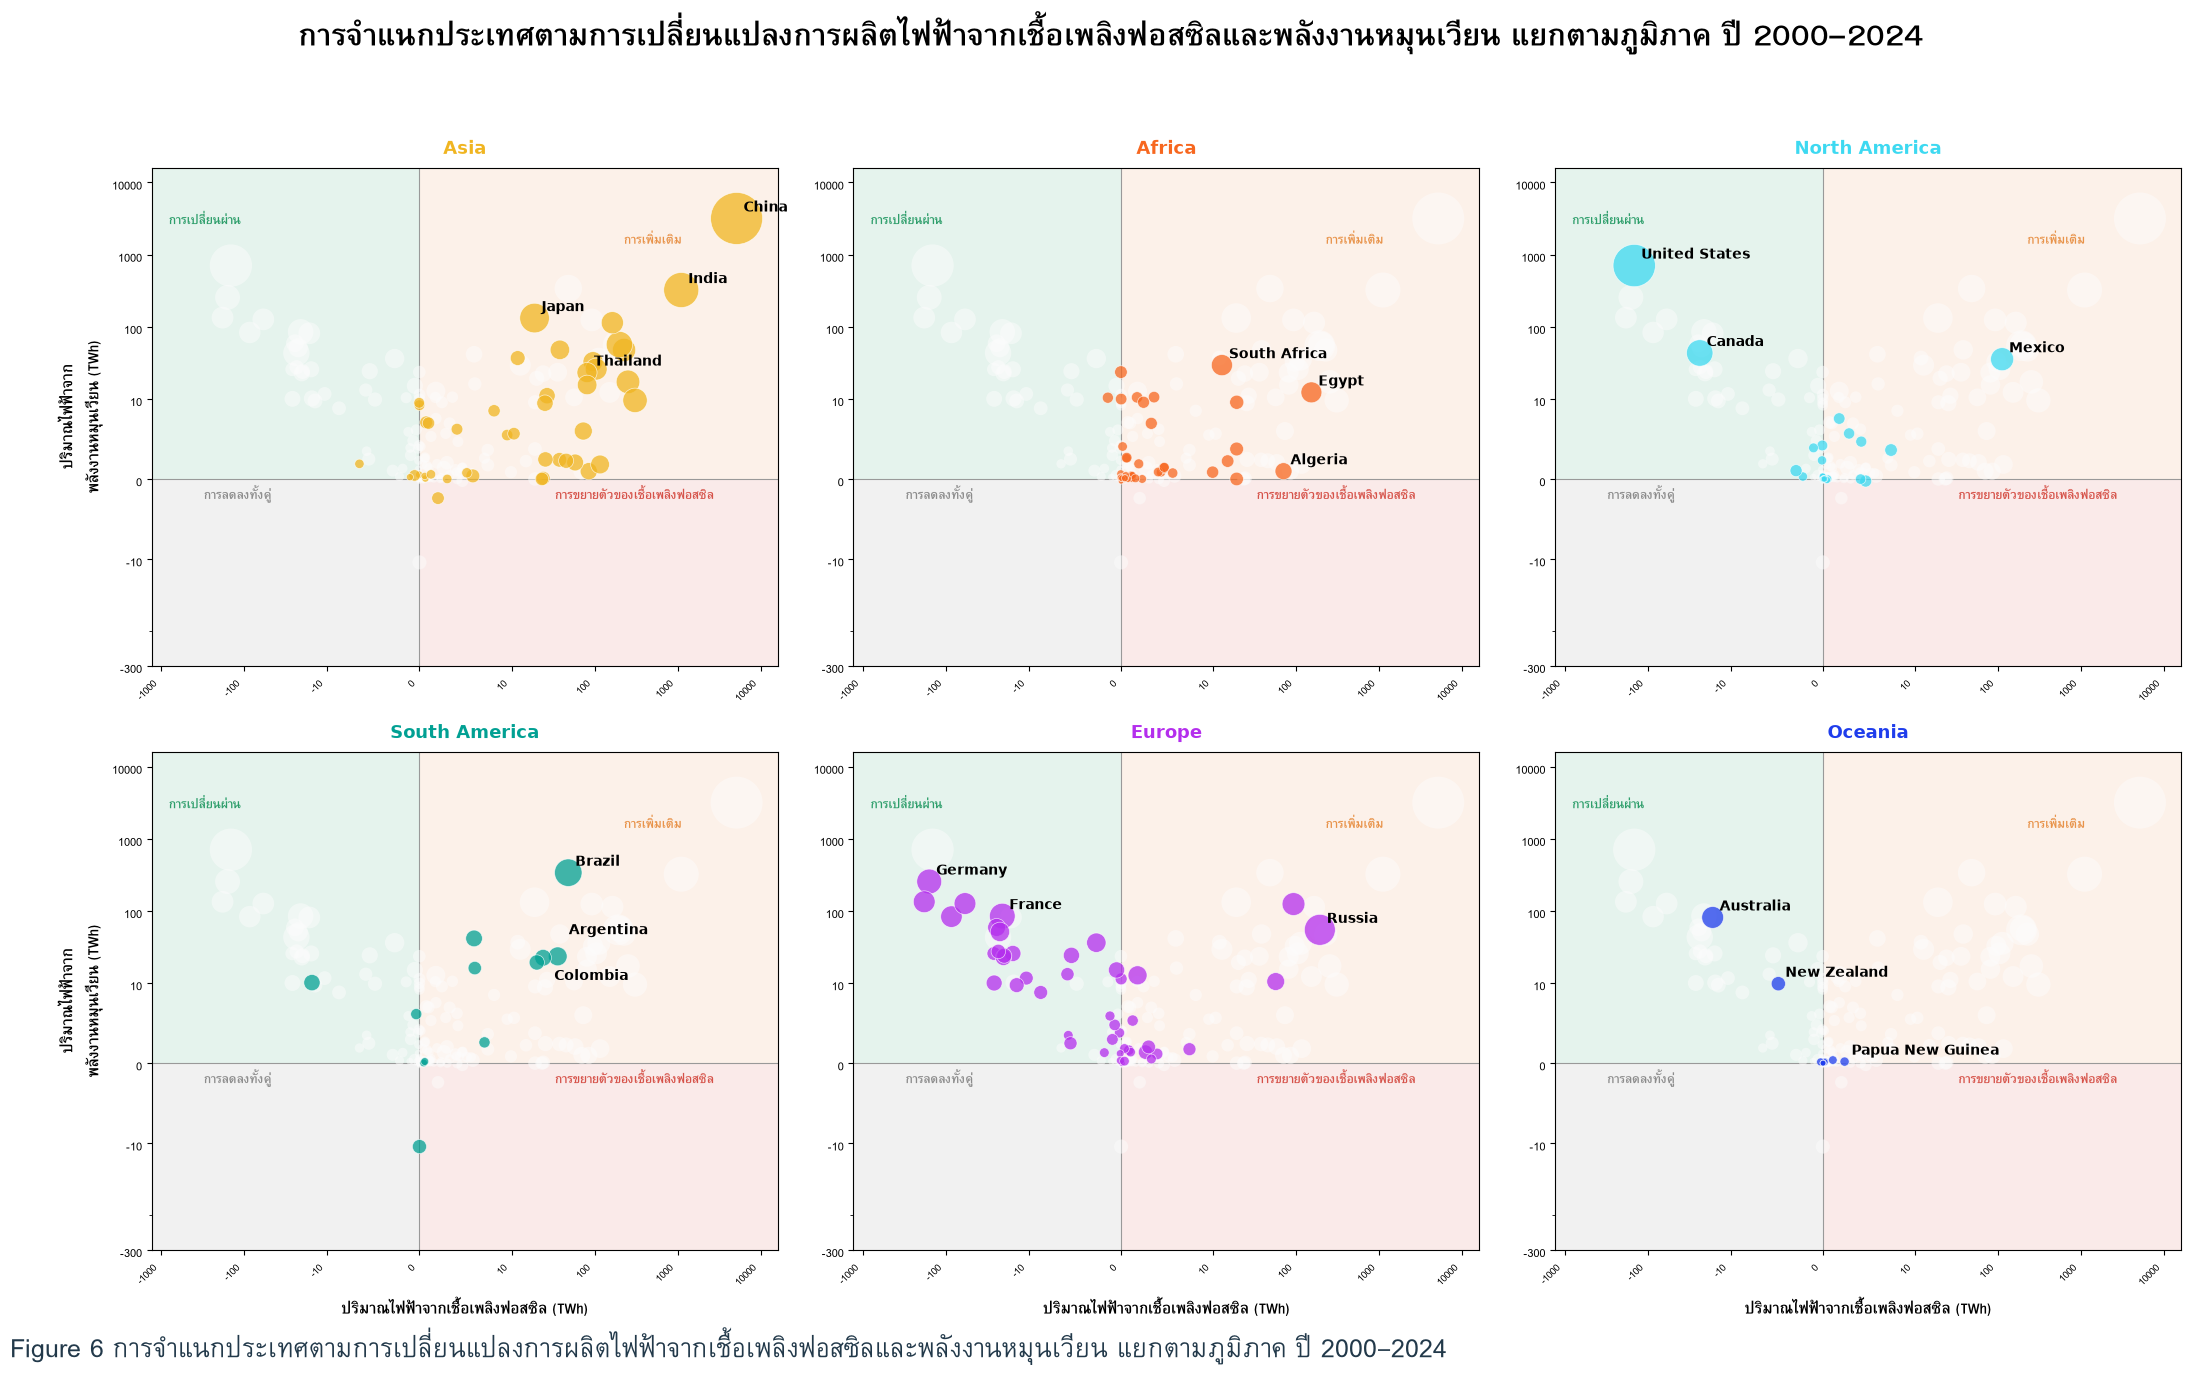

In [156]:
# ---------- 2. สีตามทวีป ----------
CONTINENT_COLORS = {
    'Asia': "#F0B521",
    'Africa': "#F7671F",
    'North America': "#3DD9F1",
    'South America': "#01A093",
    'Europe': "#B42EED",
    'Oceania': "#1F3DEC"
}
GRAY = "#fcfcfc"

# ---------- 3. ขนาด bubble จาก electricity_generation (gen_2024) - scale เดียวกันทุกกราฟย่อย ----------
size_raw = np.sqrt(m['gen_2024'].clip(lower=0.01))
size_min, size_max = 15, 1400
m['bubble_size'] = np.interp(size_raw, (size_raw.min(), size_raw.max()), (size_min, size_max))

# ---------- 4. เลือกป้ายชื่อ: 3 ประเทศใหญ่สุด (ตาม gen_2024) ต่อทวีป + ไทย (ในทวีปเอเชีย) ----------
top3_idx = m.groupby('continent')['gen_2024'].nlargest(3).index.get_level_values(1)
label_idx = set(top3_idx)
thailand_idx = m[m['country'] == 'Thailand'].index
label_idx.update(thailand_idx)
m['show_label'] = m.index.isin(label_idx)

# ---------- 5. แกน (scale เดียวกันทุกกราฟ แบบ symlog เหมือน Figure 7) ----------
LINTHRESH = 10
XLIM_4 = (-1300, 16000)
YLIM_4 = (-300, 16000)

X_TICKS = [-1000, -100, -10, 0, 10, 100, 1000, 10000]
Y_TICKS = [-300, -10, 0, 10, 100, 1000, 10000]

# ---------- 5b. สี quadrant: ใช้ชุดเดียวกับกราฟ Bubble รวม (Cell 3) ----------
COLOR_ORANGE = '#E8934A'   # การเพิ่มเติม
COLOR_GREEN  = '#2E9E6B'   # การเปลี่ยนผ่าน
COLOR_RED    = '#D6534A'   # การขยายตัวของเชื้อเพลิงฟอสซิล
COLOR_GRAY   = '#8C8C8C'   # การลดลงทั้งคู่

QUADRANT_COLOR = {
    'การเพิ่มเติม': COLOR_ORANGE,
    'การเปลี่ยนผ่าน': COLOR_GREEN,
    'การขยายตัวของเชื้อเพลิงฟอสซิล': COLOR_RED,
    'การลดลงทั้งคู่': COLOR_GRAY,
}
QUADRANT_BG_ALPHA = 0.12   # เท่ากับกราฟ Bubble รวม

# ป้ายชื่อ quadrant บนพื้นหลังสี (ครบทั้ง 4 quadrant)
quadrant_label_pos = {
    'การเพิ่มเติม': (500, 1600),
    'การเปลี่ยนผ่าน': (-300, 3000),
    'การขยายตัวของเชื้อเพลิงฟอสซิล': (300, -2),
    'การลดลงทั้งคู่': (-120, -2),
}

def add_quadrant_labels(ax, positions):
    for label, (x, y) in positions.items():
        ax.text(x, y, label,
                fontsize=8, fontfamily=GARUDA, fontweight='bold',
                color=QUADRANT_COLOR[label], alpha=1.0,
                ha='center', va='center', zorder=1.5)

def add_quadrant_bg(ax, xlim, ylim):
    ax.add_patch(Rectangle((0, 0), xlim[1], ylim[1],
                            facecolor=QUADRANT_COLOR['การเพิ่มเติม'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))
    ax.add_patch(Rectangle((xlim[0], 0), 0 - xlim[0], ylim[1],
                            facecolor=QUADRANT_COLOR['การเปลี่ยนผ่าน'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))
    ax.add_patch(Rectangle((0, ylim[0]), xlim[1], 0 - ylim[0],
                            facecolor=QUADRANT_COLOR['การขยายตัวของเชื้อเพลิงฟอสซิล'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))
    ax.add_patch(Rectangle((xlim[0], ylim[0]), 0 - xlim[0], 0 - ylim[0],
                            facecolor=QUADRANT_COLOR['การลดลงทั้งคู่'], edgecolor='none',
                            alpha=QUADRANT_BG_ALPHA, zorder=0))

# ---------- 6. วาดกราฟ 2x3 ----------
continents = ['Asia', 'Africa', 'North America', 'South America', 'Europe', 'Oceania']
fig, axes = plt.subplots(2, 3, figsize=(22, 14))   # ขยายขนาดรูป
axes = axes.flatten()

# ปรับตำแหน่ง offset ของป้ายชื่อประเทศเฉพาะจุดที่ชิด/ทับกัน (หน่วย points จากจุดศูนย์กลางฟอง)
LABEL_OFFSET_OVERRIDES = {
    'Argentina': (8, 16),
    'Colombia': (8, -16),
}
DEFAULT_LABEL_OFFSET = (5, 5)

for i, cont in enumerate(continents):
    ax = axes[i]
    color = CONTINENT_COLORS[cont]

    # ทวีปอื่น -> สีเทาอ่อน (พื้นหลัง)
    other = m[m['continent'] != cont]
    ax.scatter(other['delta_fossil'], other['delta_ren'], s=other['bubble_size'],
               color=GRAY, alpha=0.5, edgecolor='none', zorder=2)

    # ทวีปนี้ -> สีของทวีป
    sub = m[m['continent'] == cont]
    ax.scatter(sub['delta_fossil'], sub['delta_ren'], s=sub['bubble_size'],
               color=color, alpha=0.75, edgecolor='white', linewidth=0.5, zorder=3)

    # เส้นแบ่ง quadrant ที่ 0
    ax.axhline(0, color='#999999', linewidth=0.8, zorder=1)
    ax.axvline(0, color='#999999', linewidth=0.8, zorder=1)

    # พื้นหลังสี quadrant
    add_quadrant_bg(ax, XLIM_4, YLIM_4)
    add_quadrant_labels(ax, quadrant_label_pos)

    # ป้ายชื่อประเทศ (เฉพาะของทวีปนี้) - แก้ทับกัน + ตัวหนา
    labels = sub[sub['show_label']]
    for _, r in labels.iterrows():
        dx, dy = LABEL_OFFSET_OVERRIDES.get(r['country'], DEFAULT_LABEL_OFFSET)
        ax.annotate(r['country'], (r['delta_fossil'], r['delta_ren']),
                    xytext=(dx, dy), textcoords='offset points',
                    fontsize=10, fontfamily=DEJAVU, fontweight='bold',
                    color='#000000', zorder=4)

    # ชื่อทวีป (เหนือกราฟ)
    ax.set_title(cont, fontsize=13, fontfamily=DEJAVU, fontweight='bold', color=color, pad=10)

    # scale และแกน
    ax.set_xscale('symlog', linthresh=LINTHRESH, linscale=1)
    ax.set_yscale('symlog', linthresh=LINTHRESH, linscale=1)
    ax.set_xlim(XLIM_4)
    ax.set_ylim(YLIM_4)
    ax.set_xticks(X_TICKS)
    ax.set_yticks(Y_TICKS)
    ax.set_xticklabels([f"{t:g}" for t in X_TICKS], fontsize=7, rotation=45, ha='right')
    ax.set_yticklabels([f"{t:g}" for t in Y_TICKS], fontsize=8)
    ax.grid(True, which='major', color='None', linewidth=0.6, zorder=1)

    # แสดงชื่อแกนเฉพาะขอบนอกของตาราง (ซ้ายสุด / แถวล่างสุด) เพื่อลดความรก
    row, col = divmod(i, 3)
    if col == 0:
        ax.set_ylabel('ปริมาณไฟฟ้าจาก\nพลังงานหมุนเวียน (TWh)', fontsize=10, fontfamily=GARUDA, fontweight='bold')
    if row == 1:
        ax.set_xlabel('ปริมาณไฟฟ้าจากเชื้อเพลิงฟอสซิล (TWh)', fontsize=10, fontfamily=GARUDA, fontweight='bold')

# ---------- หัวข้อรวม ----------
fig.suptitle('การจำแนกประเทศตามการเปลี่ยนแปลงการผลิตไฟฟ้าจากเชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน แยกตามภูมิภาค ปี 2000–2024',
             fontsize=20, fontfamily=GARUDA, fontweight='bold', color='#000000', x=0.5, y=0.985, ha='center')

# ---------- Figure caption ----------
fig.text(0.00, 0.012,
         'Figure 6 การจำแนกประเทศตามการเปลี่ยนแปลงการผลิตไฟฟ้าจากเชื้อเพลิงฟอสซิลและพลังงานหมุนเวียน แยกตามภูมิภาค ปี 2000–2024',
         fontsize=18, fontfamily=GARUDA, color='#22394a', ha='left', va='bottom')

plt.tight_layout(rect=[0.012, 0.035, 0.995, 0.955])
plt.savefig('regional_bubble_grid.svg', dpi=300, facecolor='white')
plt.savefig('regional_bubble_grid.png', dpi=300, facecolor='white')
print("saved")

#Table3-5

Saved: /mnt/user-data/outputs/table3_delta_re.png
Saved: /mnt/user-data/outputs/table4_delta_fossil.png
Saved: /mnt/user-data/outputs/table5_merge_verdict.png
DONE — all 3 tables generated.


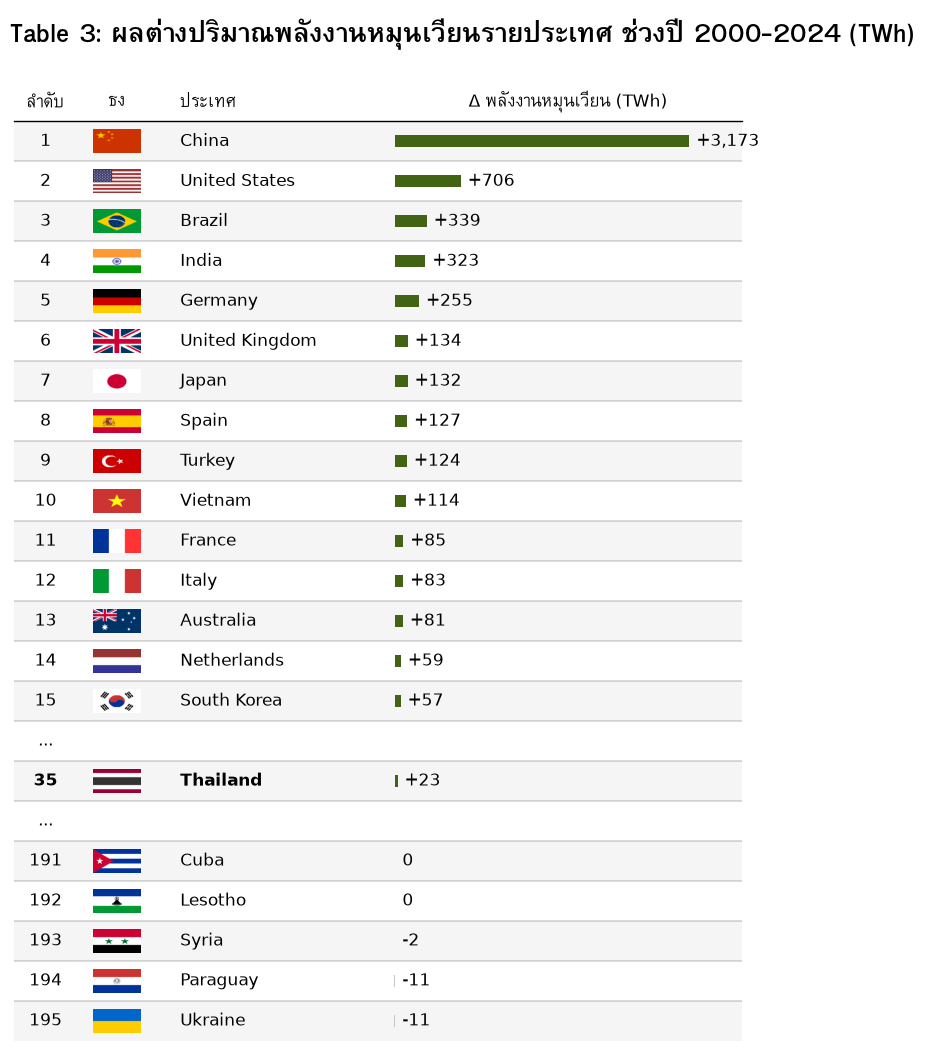

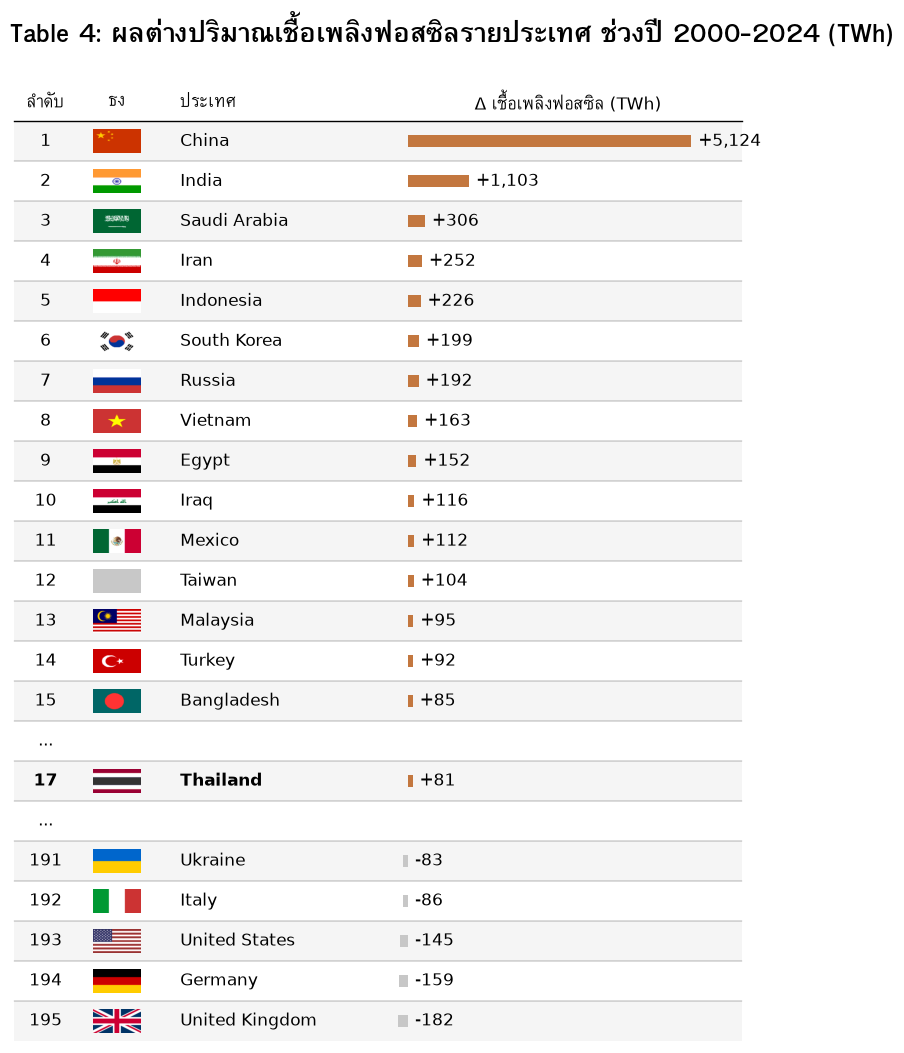

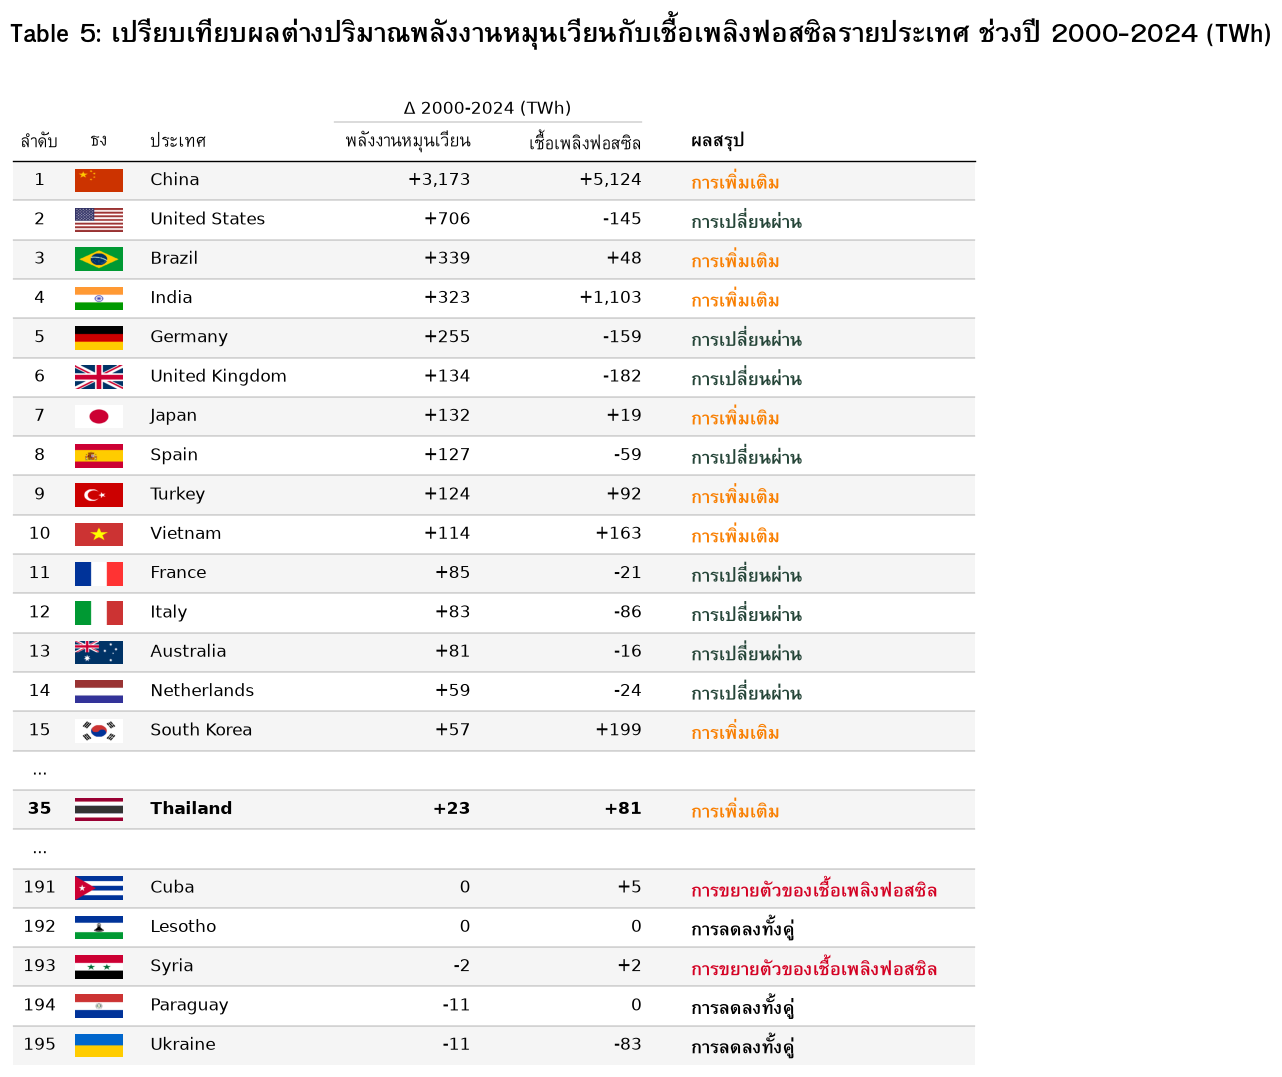

In [157]:
GARUDA_PATHS = [
    "/usr/share/fonts/truetype/tlwg/Garuda.ttf",
    "/usr/share/fonts/truetype/tlwg/Garuda-Bold.ttf",
]
for p in GARUDA_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)

THAI_FONT = ["DejaVu Sans", "Garuda"]   # ใช้กับข้อความไทย (หัวข้อ/หัวตาราง) — DejaVu นำหน้าเพื่อกัน glyph เพี้ยนตอนผสมกับอังกฤษ/ตัวเลข
EN_FONT = ["DejaVu Sans"]               # ใช้กับชื่อประเทศ / ตัวเลขล้วน

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

TITLE_SIZE = 18
BODY_SIZE = 12

# --------------------------------------------------------------------------
# 1) โหลดข้อมูล + คำนวณ Delta RE / Delta Fossil (2000 -> 2024)
# --------------------------------------------------------------------------
# RE     = solar + wind + hydro + other_renewable   (ไม่รวม nuclear / biofuel เพราะไม่มีคอลัมน์แยก)
# Fossil = coal + gas + oil

# ใช้ข้อมูล df ที่โหลดไว้ในเซลล์ Import file
table_df = df.copy()
table_df["RE"] = (
    table_df["solar_electricity"]
    + table_df["wind_electricity"]
    + table_df["hydro_electricity"]
    + table_df["other_renewable_electricity"]
)
table_df["Fossil"] = table_df["coal_electricity"] + table_df["gas_electricity"] + table_df["oil_electricity"]

pivot = table_df[table_df["year"].isin([2000, 2024])].pivot(
    index="country", columns="year", values=["RE", "Fossil"]
)
pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
pivot["delta_re"] = pivot["RE_2024"] - pivot["RE_2000"]
pivot["delta_fossil"] = pivot["Fossil_2024"] - pivot["Fossil_2000"]
pivot = pivot.dropna(subset=["delta_re", "delta_fossil"]).reset_index()

# --------------------------------------------------------------------------
# 2) เตรียมธงประเทศ (flagpy) -> เซฟเป็นไฟล์ png ให้ plottable เรียกใช้
# --------------------------------------------------------------------------
FLAG_NAME_MAP = {
    "United States": "The United States",
    "United Kingdom": "The United Kingdom",
    "United Arab Emirates": "The United Arab Emirates",
    "Czechia": "The Czech Republic",
    "Netherlands": "The Netherlands",
    "Philippines": "The Philippines",
    "Democratic Republic of Congo": "The Democratic Republic Of The Congo",
    "Congo": "The Republic Of The Congo",
    "Bahamas": "The Bahamas",
    "Gambia": "The Gambia",
    "Maldives": "The Maldives",
    "Marshall Islands": "The Marshall Islands",
    "Micronesia (country)": "The Federated States Of Micronesia",
    "Central African Republic": "The Central African Republic",
    "Comoros": "The Comoros",
    "Dominican Republic": "The Dominican Republic",
    "Timor": "East Timor",
    "Cote d'Ivoire": "Ivory Coast",
    "Sao Tome and Principe": "São Tomé And Príncipe",
    "Saint Kitts and Nevis": "Saint Kitts And Nevis",
    "Saint Vincent and the Grenadines": "Saint Vincent And The Grenadines",
    "Antigua and Barbuda": "Antigua And Barbuda",
    "Bosnia and Herzegovina": "Bosnia And Herzegovina",
    "Trinidad and Tobago": "Trinidad And Tobago",
}

FLAG_DIR = "flags"
os.makedirs(FLAG_DIR, exist_ok=True)


def get_flag_path(country: str) -> str:
    """โหลดธงจาก flagpy แล้วเซฟเป็นไฟล์ .png คืน path (มี cache กันโหลดซ้ำ)"""
    safe_name = country.replace(" ", "_").replace("/", "-")
    out_path = os.path.join(FLAG_DIR, f"{safe_name}.png")
    if os.path.exists(out_path):
        return out_path

    lookup_name = FLAG_NAME_MAP.get(country, country)
    try:
        img = fp.get_flag_img(lookup_name)
        img.save(out_path)
    except Exception:
        placeholder = Image.new("RGB", (180, 90), color=(200, 200, 200))
        placeholder.save(out_path)
    return out_path


# --------------------------------------------------------------------------
# 3) ฟังก์ชันจัดอันดับ: Top 15 + Thailand (ถ้าไม่ติด Top15) + Bottom 5
# --------------------------------------------------------------------------
N_TOP = 15
N_BOTTOM = 5


def build_rank_table(pivot_df: pd.DataFrame, sort_col: str, n_top=N_TOP, n_bottom=N_BOTTOM):
    ranked = pivot_df.sort_values(sort_col, ascending=False).reset_index(drop=True)
    ranked["No."] = ranked.index + 1

    top = ranked.head(n_top)
    bottom = ranked.tail(n_bottom)
    th_row = ranked[ranked["country"] == "Thailand"]

    parts = [top]
    if not th_row.empty and th_row["No."].iloc[0] not in top["No."].values:
        parts.append(th_row)
    parts.append(bottom)

    out = pd.concat(parts).drop_duplicates(subset="No.").sort_values("No.")
    return out.reset_index(drop=True)


# --------------------------------------------------------------------------
# 3b) แทรกแถวคั่น "..." ตรงจุดที่อันดับกระโดดข้าม (เช่น 15 -> 35 -> 191)
#     ใส่ "..." เฉพาะคอลัมน์ลำดับ ส่วนคอลัมน์อื่นเว้นว่างไว้
# --------------------------------------------------------------------------
def insert_gap_rows(df: pd.DataFrame, rank_col: str) -> pd.DataFrame:
    df = df.reset_index(drop=True)
    out_rows = []
    prev_no = None
    gap_id = 0  # ใช้เป็นเลขติดลบ ไม่ซ้ำกัน เผื่อมีมากกว่า 1 จุดกระโดด
    for _, row in df.iterrows():
        cur_no = row[rank_col]
        if prev_no is not None and (cur_no - prev_no) > 1:
            gap_id -= 1
            gap_row = {}
            for col in df.columns:
                if col == rank_col:
                    gap_row[col] = gap_id  # sentinel ติดลบ -> format เป็น "..."
                elif pd.api.types.is_numeric_dtype(df[col]):
                    gap_row[col] = np.nan
                else:
                    gap_row[col] = ""  # ว่างไว้ (ไม่ใช่ None กัน str(None) โชว์คำว่า "None")
            out_rows.append(gap_row)
        out_rows.append(row.to_dict())
        prev_no = cur_no
    return pd.DataFrame(out_rows)


def format_rank(v) -> str:
    """แสดงเลขลำดับปกติ หรือ '...' สำหรับแถวคั่น (sentinel ติดลบ)"""
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return "..."
    if v < 0:
        return "..."
    return f"{int(v)}"


# --------------------------------------------------------------------------
# 4) ตัวช่วยจัดรูปแบบตัวเลข -> เครื่องหมาย +/- และจำนวนเต็ม (ไม่มีทศนิยม)
# --------------------------------------------------------------------------
def format_plusminus(val) -> str:
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return ""
    v = round(val)
    if v == 0:
        return "0"
    return f"{v:+,}"


# --------------------------------------------------------------------------
# 4a) วาดธงแบบปลอดภัย: ถ้าไม่มี path (แถวคั่น) ให้เว้นว่าง ไม่ error
# --------------------------------------------------------------------------
def safe_image(ax, path):
    ax.axis("off")
    if path is None or (isinstance(path, float) and pd.isna(path)) or path == "":
        return
    return image(ax, path)


# --------------------------------------------------------------------------
# 4b) Custom bar-in-cell: ตัวเลขอยู่ "นอกแท่งเสมอ" (กันตัวเลขทับแท่งสีเข้ม)
#     ค่าติดลบ -> แท่งสีเทาอ่อน (แยกให้เห็นชัดจากค่าบวก)
# --------------------------------------------------------------------------
NEG_BAR_COLOR = "#C7C7C7"


def bar_outside_label(ax, val, xlim, pos_color, neg_color=NEG_BAR_COLOR,
                       formatter=format_plusminus, textprops=None, bar_height=0.5):
    textprops = textprops or {}
    ax.set_xlim(xlim)
    ax.set_ylim(0, 1)
    ax.axis("off")

    if val is None or (isinstance(val, float) and pd.isna(val)):
        return  # แถวคั่น "..." -> ไม่วาดอะไรในคอลัมน์นี้

    color = pos_color if val >= 0 else neg_color
    ax.barh(0.5, val, height=bar_height, color=color, ec="None", zorder=0.05)

    text = formatter(val)
    pad = 0.02 * (xlim[1] - xlim[0])  # ระยะห่างคงที่จากปลายแท่ง / จากเส้นศูนย์
    # ข้อความอยู่ "ทางขวาเสมอ" ไม่ว่าค่าจะบวกหรือลบ (อ่านง่าย เรียงแนวเดียวกัน)
    x = val + pad if val >= 0 else pad
    ax.text(x, 0.5, text, va="center", ha="left", zorder=0.3, **textprops)


# --------------------------------------------------------------------------
# 5) Verdict logic (ตาม Four Quadrants)
# --------------------------------------------------------------------------
def get_verdict(row):
    re_up = row["delta_re"] > 0
    fossil_up = row["delta_fossil"] > 0
    if fossil_up and re_up:
        return "การเพิ่มเติม"
    elif (not fossil_up) and re_up:
        return "การเปลี่ยนผ่าน"
    elif fossil_up and (not re_up):
        return "การขยายตัวของเชื้อเพลิงฟอสซิล"
    else:
        return "การลดลงทั้งคู่"


VERDICT_COLORS = {
    "การเปลี่ยนผ่าน": "#254538",
    "การเพิ่มเติม": "#F97F01",
    "การขยายตัวของเชื้อเพลิงฟอสซิล": "#D40123",
    "การลดลงทั้งคู่": "#000000",
}


def bold_country_row(tab: Table, table_df: pd.DataFrame, country="Thailand",
                      country_col="country", col_names=None):
    """ทำให้แถวของ 'country' (เช่น Thailand) เป็นตัวหนาทุกคอลัมน์ข้อความที่กำหนด"""
    row_idx = table_df.index[table_df[country_col] == country]
    if len(row_idx) == 0:
        return
    row_idx = row_idx[0]
    if col_names is None:
        col_names = table_df.columns
    for col in col_names:
        try:
            column = tab.columns[col]
        except KeyError:
            continue
        cell = column.cells[row_idx]
        if hasattr(cell, "text"):
            cell.text.set_fontweight("bold")


def set_column_font(tab: Table, col_name: str, font_list):
    """ตั้งฟอนต์ของ 'เนื้อหา' cells ในคอลัมน์ (ไม่รวมหัวตาราง) เป็น font_list ที่กำหนด"""
    try:
        column = tab.columns[col_name]
    except KeyError:
        return
    for cell in column.cells:
        if hasattr(cell, "text"):
            cell.text.set_fontfamily(font_list)


def save_fig(fig, path):
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    print("Saved:", path)


def draw_split_title(ax, prefix: str, thai_rest: str, fontsize=TITLE_SIZE, y=1.04):
    """Use the same Garuda font, size and baseline for the complete title."""
    return ax.text(
        0.0, y, prefix + thai_rest,
        transform=ax.transAxes, ha="left", va="baseline",
        fontsize=fontsize, fontweight="bold", fontfamily="Garuda",
    )


os.makedirs("/mnt/user-data/outputs", exist_ok=True)

# ==========================================================================
# TABLE 3: ตารางอันดับประเทศตามผลต่างพลังงานหมุนเวียน (Delta RE) — ไฮไลท์ไทย
# ==========================================================================
t3 = build_rank_table(pivot, "delta_re")
t3["flag_path"] = t3["country"].apply(get_flag_path)
t3_display = t3[["No.", "flag_path", "country", "delta_re"]].copy()
t3_display.columns = ["ลำดับ", "ธง", "ประเทศ", "Δ พลังงานหมุนเวียน (TWh)"]

re_max = t3_display["Δ พลังงานหมุนเวียน (TWh)"].max()
re_min = t3_display["Δ พลังงานหมุนเวียน (TWh)"].min()

t3_display = insert_gap_rows(t3_display, rank_col="ลำดับ")

col_defs_3 = [
    ColumnDefinition(name="ลำดับ", width=0.4, formatter=format_rank, textprops={"ha": "center"}),
    ColumnDefinition(name="ธง", width=0.5, plot_fn=safe_image, textprops={"ha": "center"}),
    ColumnDefinition(name="ประเทศ", width=1.5, textprops={"ha": "left"}),
    ColumnDefinition(
        name="Δ พลังงานหมุนเวียน (TWh)",
        width=2.2,
        plot_fn=partial(
            bar_outside_label,
            xlim=(min(0, re_min * 1.4), re_max * 1.18),
            pos_color="#426214",
            formatter=format_plusminus,
            textprops={"fontsize": BODY_SIZE, "fontfamily": EN_FONT},
            bar_height=0.5,
        ),
    ),
]

fig3, ax3 = plt.subplots(figsize=(9.5, len(t3_display) * 0.5 + 1))
tab3 = Table(
    t3_display,
    index_col="ลำดับ",
    column_definitions=col_defs_3,
    row_dividers=True,
    col_label_divider=True,
    footer_divider=False,
    textprops={"fontsize": BODY_SIZE, "ha": "center", "fontfamily": THAI_FONT},
    even_row_color="#f5f5f5",
    ax=ax3,
)
set_column_font(tab3, "ประเทศ", EN_FONT)
bold_country_row(
    tab3,
    t3_display.reset_index(drop=True),
    country="Thailand",
    country_col="ประเทศ",
    col_names=["ประเทศ", "Δ พลังงานหมุนเวียน (TWh)", "ลำดับ"],
)
draw_split_title(
    ax3, "Table 3: ",
    "ผลต่างปริมาณพลังงานหมุนเวียนรายประเทศ ช่วงปี 2000-2024 (TWh)",
)
save_fig(fig3, "/mnt/user-data/outputs/table3_delta_re.png")


# ==========================================================================
# TABLE 4: ตารางอันดับประเทศตามผลต่างเชื้อเพลิงฟอสซิล (Delta Fossil) — ไฮไลท์ไทย
# ==========================================================================
t4 = build_rank_table(pivot, "delta_fossil")
t4["flag_path"] = t4["country"].apply(get_flag_path)
t4_display = t4[["No.", "flag_path", "country", "delta_fossil"]].copy()
t4_display.columns = ["ลำดับ", "ธง", "ประเทศ", "Δ เชื้อเพลิงฟอสซิล (TWh)"]

fossil_max = t4_display["Δ เชื้อเพลิงฟอสซิล (TWh)"].max()
fossil_min = t4_display["Δ เชื้อเพลิงฟอสซิล (TWh)"].min()

t4_display = insert_gap_rows(t4_display, rank_col="ลำดับ")

col_defs_4 = [
    ColumnDefinition(name="ลำดับ", width=0.4, formatter=format_rank, textprops={"ha": "center"}),
    ColumnDefinition(name="ธง", width=0.5, plot_fn=safe_image, textprops={"ha": "center"}),
    ColumnDefinition(name="ประเทศ", width=1.5, textprops={"ha": "left"}),
    ColumnDefinition(
        name="Δ เชื้อเพลิงฟอสซิล (TWh)",
        width=2.2,
        plot_fn=partial(
            bar_outside_label,
            xlim=(min(0, fossil_min * 1.4), fossil_max * 1.18),
            pos_color="#C3773F",
            formatter=format_plusminus,
            textprops={"fontsize": BODY_SIZE, "fontfamily": EN_FONT},
            bar_height=0.5,
        ),
    ),
]

fig4, ax4 = plt.subplots(figsize=(9.5, len(t4_display) * 0.5 + 1))
tab4 = Table(
    t4_display,
    index_col="ลำดับ",
    column_definitions=col_defs_4,
    row_dividers=True,
    col_label_divider=True,
    footer_divider=False,
    textprops={"fontsize": BODY_SIZE, "ha": "center", "fontfamily": THAI_FONT},
    even_row_color="#f5f5f5",
    ax=ax4,
)
set_column_font(tab4, "ประเทศ", EN_FONT)
bold_country_row(
    tab4,
    t4_display.reset_index(drop=True),
    country="Thailand",
    country_col="ประเทศ",
    col_names=["ประเทศ", "Δ เชื้อเพลิงฟอสซิล (TWh)", "ลำดับ"],
)
draw_split_title(
    ax4, "Table 4: ",
    "ผลต่างปริมาณเชื้อเพลิงฟอสซิลรายประเทศ ช่วงปี 2000-2024 (TWh)",
)
save_fig(fig4, "/mnt/user-data/outputs/table4_delta_fossil.png")


# ==========================================================================
# TABLE 5: รวมผลต่างพลังงานหมุนเวียน + ฟอสซิล พร้อมผลสรุป เรียงตามพลังงานหมุนเวียน
# ==========================================================================
t5 = t3.copy()  # ใช้ชุดเดียวกับ Table 3 (rank by RE) เพื่อความสอดคล้อง
t5["Verdict"] = t5.apply(get_verdict, axis=1)

t5_display = t5[["No.", "flag_path", "country", "delta_re", "delta_fossil", "Verdict"]].copy()
t5_display.columns = [
    "ลำดับ", "ธง", "ประเทศ",
    "พลังงานหมุนเวียน", "เชื้อเพลิงฟอสซิล", "ผลสรุป",
]

GROUP_LABEL = "Δ 2000-2024 (TWh)"

t5_display = insert_gap_rows(t5_display, rank_col="ลำดับ")

col_defs_5 = [
    ColumnDefinition(name="ลำดับ", width=0.4, formatter=format_rank, textprops={"ha": "center"}),
    ColumnDefinition(name="ธง", width=0.5, plot_fn=safe_image, textprops={"ha": "center"}),
    ColumnDefinition(name="ประเทศ", width=1.4, textprops={"ha": "left"}),
    ColumnDefinition(
        name="พลังงานหมุนเวียน",
        width=1.3,
        formatter=format_plusminus,
        textprops={"ha": "right"},
        group=GROUP_LABEL,
    ),
    ColumnDefinition(
        name="เชื้อเพลิงฟอสซิล",
        width=1.3,
        formatter=format_plusminus,
        textprops={"ha": "right"},
        group=GROUP_LABEL,
    ),
    ColumnDefinition(
        name="ผลสรุป",
        width=2.4,
        textprops={"ha": "left", "fontweight": "bold"},
    ),
]

fig5, ax5 = plt.subplots(figsize=(12.5, len(t5_display) * 0.5 + 1.3))
tab5 = Table(
    t5_display,
    index_col="ลำดับ",
    column_definitions=col_defs_5,
    row_dividers=True,
    col_label_divider=True,
    footer_divider=False,
    textprops={"fontsize": BODY_SIZE, "ha": "center", "fontfamily": THAI_FONT},
    even_row_color="#f5f5f5",
    ax=ax5,
)
set_column_font(tab5, "ประเทศ", EN_FONT)
set_column_font(tab5, "พลังงานหมุนเวียน", EN_FONT)
set_column_font(tab5, "เชื้อเพลิงฟอสซิล", EN_FONT)
set_column_font(tab5, "ผลสรุป", THAI_FONT)

# ระบายสีตัวหนังสือคอลัมน์ผลสรุปตามนิยาม Four Quadrants
verdict_col = tab5.columns["ผลสรุป"]
for i, verdict in enumerate(t5_display["ผลสรุป"]):
    color = VERDICT_COLORS.get(verdict, "#000000")
    verdict_col.cells[i].text.set_color(color)

bold_country_row(
    tab5,
    t5_display.reset_index(drop=True),
    country="Thailand",
    country_col="ประเทศ",
    col_names=["ประเทศ", "พลังงานหมุนเวียน", "เชื้อเพลิงฟอสซิล", "ลำดับ"],
)

draw_split_title(
    ax5, "Table 5: ",
    "เปรียบเทียบผลต่างปริมาณพลังงานหมุนเวียนกับเชื้อเพลิงฟอสซิลรายประเทศ ช่วงปี 2000-2024 (TWh)",
)
save_fig(fig5, "/mnt/user-data/outputs/table5_merge_verdict.png")

print("DONE — all 3 tables generated.")

#Figure 7

จำนวนประเทศที่ Real Transition: 53
saved ticks: [0, 5, 100, 800] vmax: 800
saved base map


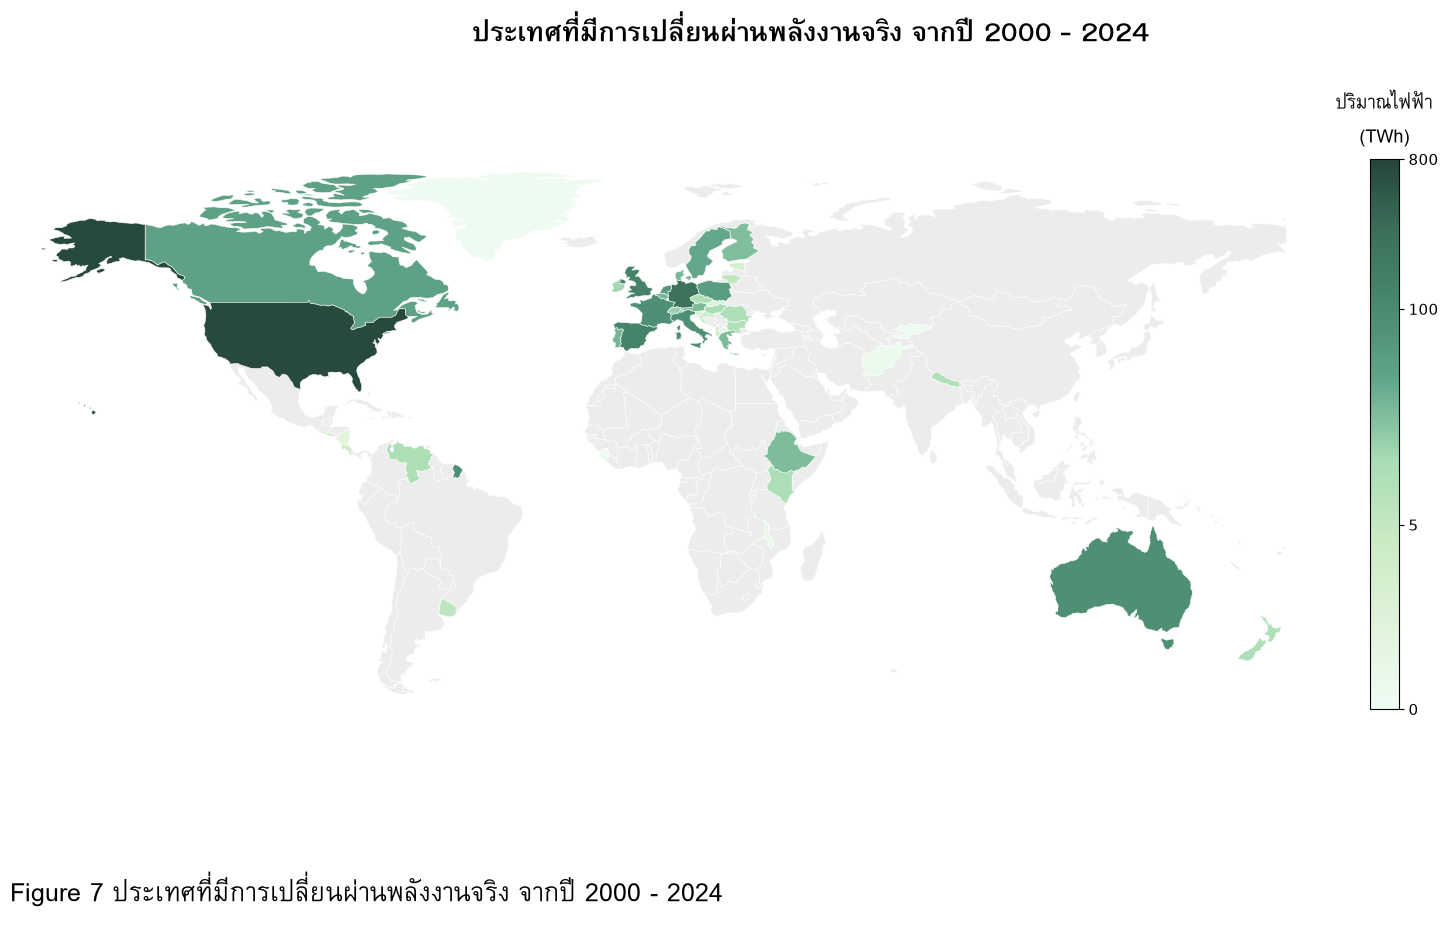

In [158]:
# ---------- คำนวนหาปริมาณไฟฟ้าปี 2000 และ 2024 ----------
# ใช้ข้อมูลที่โหลดไว้ในเซลล์ Import file
figure7_df = df.copy()

figure7_df['fossil'] = figure7_df['coal_electricity'] + figure7_df['gas_electricity'] + figure7_df['oil_electricity']
figure7_df['renewables'] = (figure7_df['hydro_electricity'] + figure7_df['solar_electricity']
                     + figure7_df['wind_electricity'] + figure7_df['other_renewable_electricity'])

p0 = figure7_df[figure7_df.year == 2000][['country', 'iso_code', 'fossil', 'renewables', 'electricity_generation']] \
        .rename(columns={'fossil': 'fossil_2000', 'renewables': 'ren_2000'})
p1 = figure7_df[figure7_df.year == 2024][['country', 'fossil', 'renewables', 'electricity_generation']] \
        .rename(columns={'fossil': 'fossil_2024', 'renewables': 'ren_2024',
                          'electricity_generation': 'gen_2024'})

m = p0.merge(p1, on='country').dropna(subset=['electricity_generation', 'gen_2024'])

# ---------- คำนวนความแตกต่างของพลังงานปี 2024-2000 เพื่อดูว่าประเทศไหนมีการเปลี่ยนแปลง ----------
m['delta_fossil'] = m['fossil_2024'] - m['fossil_2000']
m['delta_ren'] = m['ren_2024'] - m['ren_2000']

# ---------- เอาข้อมูลผลต่างมาหาเกณฑ์แยกว่าประเทศไหนมีการเปลี่ยนผ่านจริงๆ ----------
real_transition_map = m[(m['delta_fossil'] < 0) & (m['delta_ren'] > 0)].copy() #ถ้า fossil ลดลงและ renewables เพิ่มขึ้น แสดงว่าประเทศนั้นมีการเปลี่ยนผ่านจริง
real_transition_map = real_transition_map.dropna(subset=['iso_code'])

print(f"จำนวนประเทศที่ Real Transition: {len(real_transition_map)}")

# ---------- กำหนดสีของแผนที่ ----------
green_scale = [
    [0.0, "#f0fcf3"],
    [0.15, '#e0f3db'],
    [0.30, '#ccebc5'],
    [0.45, '#a8ddb5'],
    [0.60, "#61A589"],
    [0.75, "#47866C"],
    [0.88, "#3A6D59"],
    [1.0, '#254538'],
]
cmap = LinearSegmentedColormap.from_list('green_scale', green_scale, N=256)

# ---------- โหลดแผนที่โลก ----------
# แผนที่ชุดเดิมเก็บไว้ในโฟลเดอร์ maps รองรับ GeoPandas 1.x
map_candidates = [Path('maps/naturalearth_lowres.shp'),
                  Path('dads 5001/maps/naturalearth_lowres.shp')]
map_path = next((p for p in map_candidates if p.is_file()), None)
if map_path is None:
    raise FileNotFoundError('Keep the maps folder next to this notebook.')
world = gpd.read_file(map_path)
world = world[world['name'] != 'Antarctica']

merged = world.merge(real_transition_map[['iso_code', 'delta_ren']],
                      left_on='iso_a3', right_on='iso_code', how='left')

vmin = 0
vmax_raw = real_transition_map['delta_ren'].max()      
vmax = math.ceil(vmax_raw / 100) * 100                  # ปัดขึ้นเป็นเลขกลม -> 800
norm = SymLogNorm(linthresh=5, vmin=vmin, vmax=vmax)

# ---------- วาดกราฟ ----------
fig, ax = plt.subplots(figsize=(16, 10))

# ประเทศที่ไม่เข้าเงื่อนไข -> สีเทาอ่อน
world.plot(ax=ax, color='#ececec', edgecolor='white', linewidth=0.4)

# ประเทศที่ real transition -> ไล่สีเขียวตาม delta_ren (log scale)
transition_geo = merged.dropna(subset=['delta_ren'])
transition_geo.plot(ax=ax, column='delta_ren', cmap=cmap, norm=norm,
                     edgecolor='white', linewidth=0.4)
ax.set_axis_off()
ax.set_xlim(-170, 190)
ax.set_ylim(-60, 85)
ax.set_position([0.02, 0.08, 0.80, 0.78])  # กันที่ด้านขวาไว้สำหรับ colorbar

# ---------- Colorbar ----------
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar_ax = fig.add_axes([0.85, 0.20, 0.018, 0.55])  # [left, bottom, width, height] ตำแหน่งชัดเจน กึ่งกลางแนวตั้งของแผนที่
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')

# เลือกเฉพาะ tick ที่ห่างกันพอในสเกล log ไม่ให้ตัวเลขทับกัน (เช่น 500 กับ 705.7 ใกล้กันเกินไป)
candidate_ticks = [0, 5, 100, vmax]
final_ticks = [t for t in candidate_ticks if t <= vmax]

cbar.set_ticks(final_ticks)
cbar.set_ticklabels([f"{t:,.0f}" for t in final_ticks])
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=11)

# label "ปริมาณ (TWh)" อยู่กึ่งกลางด้านบนของแท่งสีพอดี
cbar.ax.set_title('ปริมาณไฟฟ้า\n(TWh)', fontsize=13, fontfamily=GARUDA , color='#000000', pad=12, loc='center')

# ---------- ชื่อหัวแผนที่ ----------
fig.suptitle('ประเทศที่มีการเปลี่ยนผ่านพลังงานจริง จากปี 2000 - 2024',
             fontsize=18, fontfamily=GARUDA,fontweight='bold',color='#000000', x=0.5, y=0.90, ha='center')

# ---------- Figure caption ----------
fig.text(0.00, 0.04,
         'Figure 7 ประเทศที่มีการเปลี่ยนผ่านพลังงานจริง จากปี 2000 - 2024',
         fontsize=18, fontfamily=GARUDA,color='#000000', ha='left', va='top')

plt.savefig('real_transition_map.svg', dpi=300, facecolor='white')
plt.savefig('real_transition_map.png', dpi=300, facecolor='white')
print("saved", "ticks:", final_ticks, "vmax:", vmax)

# ---------- บันทึกรูปที่ 1: แผนที่เปล่า ----------
plt.savefig('real_transition_map.svg', dpi=300, facecolor='white')
plt.savefig('real_transition_map.png', dpi=300, facecolor='white')
print("saved base map")
